In [1]:
### Notebook for P3D stuff!
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import jax
jax.config.update('jax_platform_name', 'gpu')
from jax.lib import xla_bridge
print("jax version",jax.__version__)
print(xla_bridge.get_backend().platform)

import numpy as np
import jax.numpy as jnp 

%pylab inline

jax version 0.4.26
gpu
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
!nvidia-smi


Thu Apr 10 10:34:02 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti      Off| 00000000:1A:00.0 Off |                  N/A |
| 17%   26C    P8                1W / 250W|     18MiB / 11264MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

/home/guoqi/.conda/envs/MAPLE/lib/python3.9/pty.py:85: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


|   4  Tesla V100-PCIE-32GB            Off| 00000000:21:00.0 Off |                    0 |
| N/A   36C    P0               26W / 250W|      0MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+----------------------+
|   5  Tesla V100-PCIE-32GB            Off| 00000000:22:00.0 Off |                    0 |
| N/A   36C    P0               26W / 250W|      0MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+----------------------+
|   6  NVIDIA GeForce RTX 2080 Ti      Off| 00000000:23:00.0 Off |                  N/A |
| 16%   29C    P8               16W / 250W|      1MiB / 11264MiB |      0%      Default |
|                                         |                      |                  N/A |
+---------

In [3]:
#from jaxpm.kernels import *
#uses jaxpm for some kernels... maybe?

In [4]:
#First things... set the redshift

z= 2.0

#set box geometry, probably should wrap this into the fiducial model file (hdf5?) to lead to less fiddling bugs

bs =  150#box size in Mpc/h
nc =  90#number of pixels per side

mesh_shape = [nc,nc,nc]
box_size = [bs,bs,bs]

ptcl_grid_shape = (nc,) * 3
ptcl_spacing = bs/nc



In [5]:
#some fourier space routines
from helper_functions import *

kvec = rfftnfreq_2d(ptcl_grid_shape, ptcl_spacing)
k = jnp.sqrt(sum(k**2 for k in kvec))
#this vector is needed for lots of fourier space transformation operations later on...
print(k.shape)

/tmp/ipykernel_187884/2721841557.py:5: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k = jnp.sqrt(sum(k**2 for k in kvec))
2025-04-10 10:34:05.104658: W external/xla/xla/service/gpu/nvptx_compiler.cc:718] The NVIDIA driver's CUDA version is 12.1 which is older than the ptxas CUDA version (12.8.93). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


(90, 90, 46)


In [6]:
#in this setup, LOS (z) is along the 0 axis, be careful when loading in data!

kz = jnp.ones(k.shape)*kvec[0]**2

kx = jnp.ones(k.shape)*(kvec[1]**2+kvec[2]**2)
#tiny deltas are added to avoid div by zero errors
kk = (kx+kz)+10**(-8)
kmu = jnp.sqrt((kz/(k**2+0.00001)))


In [7]:
np.max(k)


Array(3.264839, dtype=float32)

In [8]:
#m_array[:,0][:50].max()
from jax import jit, checkpoint, custom_vjp
from jax.scipy.ndimage import map_coordinates

#loading in fiducial model
m_array = np.load("pkell_red_CRO.npy")
m_array = jnp.array(m_array[np.where(m_array[:,1]<=4)])
kmax = m_array[-1,0]
print(m_array.shape,kmax)


(66, 3) 3.2255218


In [9]:
import jaxinterp2d

k_in = (k.flatten()/kmax*22-0.05)

l0 = np.where(m_array[:,1]==0)[0]
k_l0 = m_array[l0,0]
Pk_l0 = m_array[l0,2]
func1 = map_coordinates(Pk_l0,np.array([k_in]),mode="nearest",order=1)
func1 = func1.reshape(k.shape[0],k.shape[1],k.shape[2])

l2 = np.where(m_array[:,1]==2)[0]
k_l2 = m_array[l2,0]
Pk_l2 = m_array[l2,2]
func2 = map_coordinates(Pk_l2,np.array([k_in]),mode="nearest",order=1)
func2 = func2.reshape(k.shape[0],k.shape[1],k.shape[2])

l4 = np.where(m_array[:,1]==4)[0]
k_l4 = m_array[l4,0]
Pk_l4 = m_array[l4,2]
func4 = map_coordinates(Pk_l4,np.array([k_in]),mode="nearest",order=1)
func4 = func4.reshape(k.shape[0],k.shape[1],k.shape[2])

# l6 = np.where(m_array[:,1]==6)[0]
# k_l6 = m_array[l6,0]
# Pk_l6 = m_array[l6,2]
# func6 = map_coordinates(Pk_l6,np.array([k_in]),mode="nearest",order=1)
# func6 = func6.reshape(k.shape[0],k.shape[1],k.shape[2])

# l8 = np.where(m_array[:,1]==8)[0]
# k_l8 = m_array[l8,0]
# Pk_l8 = m_array[l8,2]
# func8 = map_coordinates(Pk_l8,np.array([k_in]),mode="nearest",order=1)
# func8 = func8.reshape(k.shape[0],k.shape[1],k.shape[2])

# l10 = np.where(m_array[:,1]==10)[0]
# k_l10 = m_array[l10,0]
# Pk_l10 = m_array[l10,2]
# func10 = map_coordinates(Pk_l10,np.array([k_in]),mode="nearest",order=1)
# func10 = func10.reshape(k.shape[0],k.shape[1],k.shape[2])

# l12 = np.where(m_array[:,1]==12)[0]
# k_l12 = m_array[l12,0]
# Pk_l12 = m_array[l12,2]
# func12 = map_coordinates(Pk_l12,np.array([k_in]),mode="nearest",order=1)
# func12 = func12.reshape(k.shape[0],k.shape[1],k.shape[2])


In [10]:
# plt.plot(k_l0,Pk_l0,color='red')
# plt.scatter(np.array([k_in])[0],map_coordinates(Pk_l0,np.array([k_in]),mode="nearest",order=3),s=3)
# plt.xlabel("k")
# plt.ylabel("Pk")
# plt.title(r"$\ell=0$")
# plt.loglog()

In [11]:
k_l0

Array([0.11023294, 0.24079579, 0.3849614 , 0.53187305, 0.67934203,
       0.829595  , 0.979204  , 1.1278282 , 1.2777677 , 1.4273715 ,
       1.5772808 , 1.727293  , 1.8769451 , 2.0266526 , 2.1764505 ,
       2.3265052 , 2.4766672 , 2.6267817 , 2.7766607 , 2.9265242 ,
       3.0764768 , 3.2255218 ], dtype=float32)

In [12]:
from scipy.special import legendre

np.min(func1*legendre(0)(kmu)+func2*legendre(2)(kmu)+func4*legendre(4)(kmu))

Array(0.04156275, dtype=float32)

In [13]:
k_ind_optim_max = 20
ell_bins=3
k_bins=22
tff = m_array[:,2].reshape(ell_bins,k_bins)
theta_fid = m_array[:,2].reshape(ell_bins,k_bins)[:,:k_ind_optim_max]
# theta_fid = m_array[:k_bins,2].reshape(1,k_bins)[:,:k_ind_optim_max]

from scipy.special import legendre

def power_b(theta,tff=tff):    
    tff = tff.at[:,:k_ind_optim_max].set(theta.reshape(ell_bins,k_ind_optim_max))
    # tff = tff.at[0,:k_ind_optim_max].set(theta.reshape(1,k_ind_optim_max).ravel())
    func1 = map_coordinates(tff[0], np.array([k_in]), mode="nearest", order=1)
    func1 = func1.reshape(k.shape[0],k.shape[1],k.shape[2])
    func2 = map_coordinates(tff[1], np.array([k_in]), mode="nearest", order=1)
    func2 = func2.reshape(k.shape[0],k.shape[1],k.shape[2])
    func4 = map_coordinates(tff[2], np.array([k_in]), mode="nearest", order=1)
    func4 = func4.reshape(k.shape[0],k.shape[1],k.shape[2])
    # func6 = map_coordinates(tff[3], np.array([k_in]), mode="nearest", order=1)
    # func6 = func6.reshape(k.shape[0],k.shape[1],k.shape[2])
    # func8 = map_coordinates(tff[4], np.array([k_in]), mode="nearest", order=1)
    # func8 = func8.reshape(k.shape[0],k.shape[1],k.shape[2])
    # func10 = map_coordinates(tff[5], np.array([k_in]), mode="nearest", order=1)
    # func10 = func10.reshape(k.shape[0],k.shape[1],k.shape[2])
    # func12 = map_coordinates(tff[6], np.array([k_in]), mode="nearest", order=1)
    # func12 = func12.reshape(k.shape[0],k.shape[1],k.shape[2])
    # func = jax.nn.relu(func1*legendre(0)(kmu)+func2*legendre(2)(kmu)+func4*legendre(4)(kmu)+func6*legendre(6)(kmu)+func8*legendre(8)(kmu))
    func = jax.nn.relu(func1*legendre(0)(kmu)+func2*legendre(2)(kmu)+func4*legendre(4)(kmu))
    return func/4


In [14]:
#muse componenet...
from functools import partial
import jax
import jax.numpy as jnp
from muse_inference.jax import JaxMuseProblem

In [15]:

#file name
prefix = "V1_DENSE_"
loc = "./configs/"

naa = np.load(loc+prefix+"naa.npy")
kernel = np.load(loc+prefix+"kernel.npy")
skewers_skn = np.load(loc+prefix+"skewers_skn.npy")
skewers_dla = np.load(loc+prefix+"skewers_dla.npy")
skewers_fin = np.load(loc+prefix+"skewers_fin.npy")



@jit
def cic_readout_jit_jnc(mesh,naa,kernel,bs=False):
    #"highly optimized" CIC, need to preprocess lots of things... don't diff output coords
    meshvals = mesh.flatten()[naa].reshape(-1,8).T#mesh[tuple(neighboor_coords[0,:,:].T.tolist())]
    weightedvals = meshvals.T* kernel[0]
    values = np.sum(weightedvals, axis=-1)
    
    return values



In [16]:
tf_cut_flat = theta_fid.flatten()

noise_level = 1.0

def gen_map_lya(theta,z):
    modes = z[:nc**3].reshape((nc,nc,nc))    
    Plin = power_b(theta)
    conv_field = jnp.fft.rfftn(modes).conj()*Plin**(1/2)
    lin_modes_real = jnp.fft.irfftn(conv_field).T[:,:,:]

    lya_values = cic_readout_jit_jnc(lin_modes_real,naa,kernel)
    return lya_values
                 
class Jax3DMuseProblem_flat(JaxMuseProblem):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    #@jax.jit
    def sample_x_z(self, key, θ):
        keys = jax.random.split(key, 2)
        z = jax.random.normal(keys[0], (nc*nc*nc,))
        
        # x = gen_map_lya(θ,z) + (0.05*skewers_skn)*jax.random.normal(keys[1], (kernel.shape[1],)) #1*jax.random.normal(keys[1], (32**3,)).reshape((32,32,32))
        x = gen_map_lya(θ,z) + (0.25*skewers_skn)*jax.random.normal(keys[1], (kernel.shape[1],)) #1*jax.random.normal(keys[1], (32**3,)).reshape((32,32,32))

        # return (x, z),gen_map_lya(θ,z),(1*skewers_skn)*jax.random.normal(keys[1], (kernel.shape[1],))
        return (x, z)

  #  @jax.jit
    def logLike(self, x, z, θ):
        # return -(jnp.sum((x - gen_map_lya(θ,z))**2/((0.05*skewers_skn)**2))+ jnp.sum(z**2.0))
        return -(jnp.sum((x - gen_map_lya(θ,z))**2/((0.25*skewers_skn)**2))+ jnp.sum(z**2.0))

  #  @jax.jit
    def logPrior(self, θ):
        return -jnp.sum(((θ-jnp.array(tf_cut_flat)*1.1)**2 / (2*(tf_cut_flat*0.4)**2)))
    


In [21]:
prob = Jax3DMuseProblem_flat(implicit_diff=True,jit=False)
key = jax.random.PRNGKey(100)
(x, z), map_gen, noise = prob.sample_x_z(key, tf_cut_flat)
prob.set_x(x)

(0.0, 4.0)

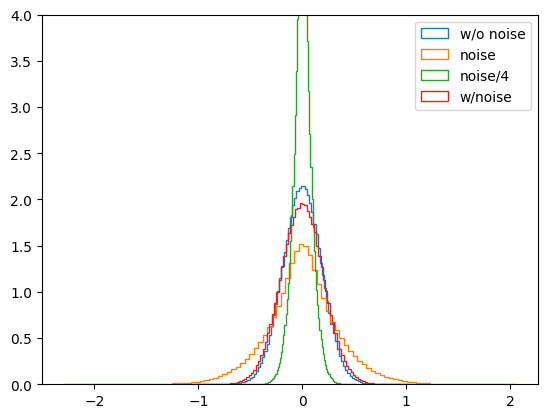

In [44]:
plt.hist(map_gen,bins=100,histtype='step',label='w/o noise',density=True)
plt.hist(noise,bins=100,histtype='step',label='noise',density=True)
plt.hist(0.25*noise,bins=100,histtype='step',label='noise/4',density=True)
plt.hist(map_gen+0.25*noise,bins=100,histtype='step',label='w/noise',density=True)
plt.legend()
plt.ylim(ymax=4)

In [34]:
np.mean(map_gen)

Array(-0.00287529, dtype=float32)

In [35]:
np.mean(noise)

Array(6.250617e-05, dtype=float32)

In [17]:
prob = Jax3DMuseProblem_flat(implicit_diff=True,jit=False)
key = jax.random.PRNGKey(100)
(x, z) = prob.sample_x_z(key, tf_cut_flat)
prob.set_x(x)

In [18]:
modes = z[:nc**3].reshape((nc,nc,nc))    
Plin = power_b(tf_cut_flat)
conv_field = jnp.fft.rfftn(modes).conj()*Plin**(1/2)
lin_modes_real = jnp.fft.irfftn(conv_field).T[:,:,:]

np.save("example_gen_field",lin_modes_real)

In [19]:
rng = jax.random.PRNGKey(1)

In [20]:
x_data = x

In [21]:
from numpy.random import SeedSequence, default_rng
from copy import copy

start_point = jnp.array(tf_cut_flat)*1.2#+np.random.randn(len(tf_cut_flat))*jnp.array(tf_cut_flat)*0.01)

def _split_rng(rng, N):
    keyz = []
    for i in range(N):
        rng, subkey = jax.random.split(rng)
        keyz.append(rng)
    return keyz
    
θ = start_point

maxsteps = 200
nsims= 10
rng = jax.random.PRNGKey(1)

xz_sims = [prob.sample_x_z(_rng, θ) for _rng in _split_rng(rng, nsims)]
xs = [x_data] + [x for (x,_) in xz_sims]
ẑs = [z*0]     + [z*0 for (x, z) in xz_sims]

In [22]:
print(x_data)

[ 0.13622198  0.3618676   0.29195842 ... -0.2948303  -0.04812637
 -0.1672704 ]


In [23]:
from jax import grad, hessian, jacfwd, jvp, value_and_grad, vmap

def gradθ_hessθ_logPrior(θ, transformed_θ=None):
        g = grad(prob.logPrior)(θ)
        H = hessian(lambda θ_vec: prob.logPrior(unravel_θ(θ_vec)))(ravel_θ(θ))
        return (g, H)

step: 1 0.7
step: 2 0.7
step: 3 0.7


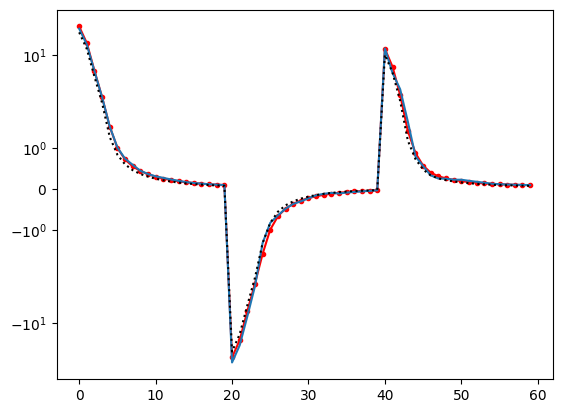

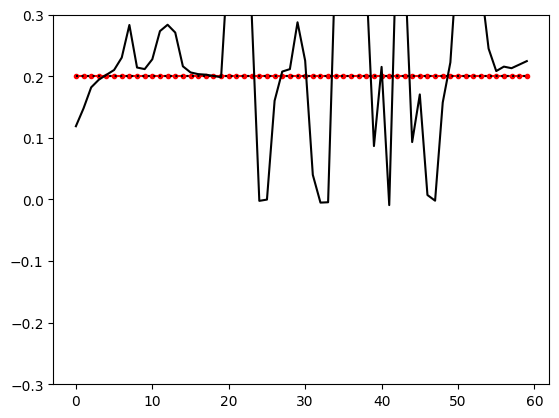

step: 4 0.6649999999999999
step: 5 0.6649999999999999
step: 6 0.6649999999999999


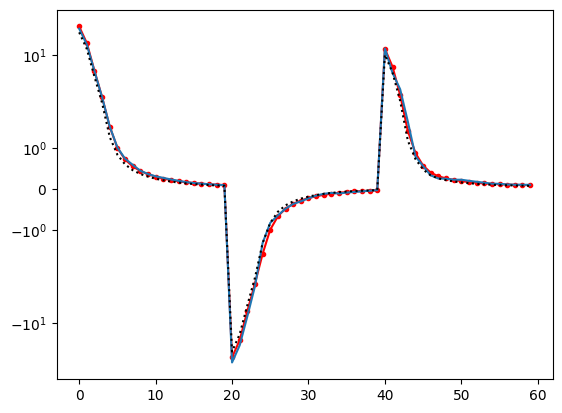

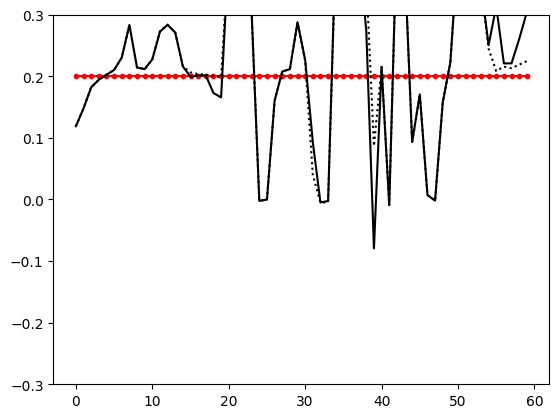

step: 7 0.6317499999999999
step: 8 0.6317499999999999
step: 9 0.6317499999999999


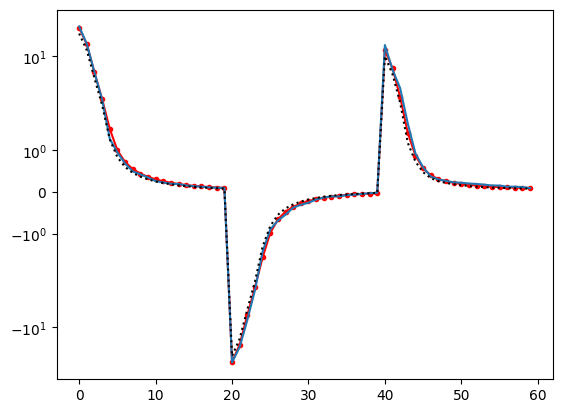

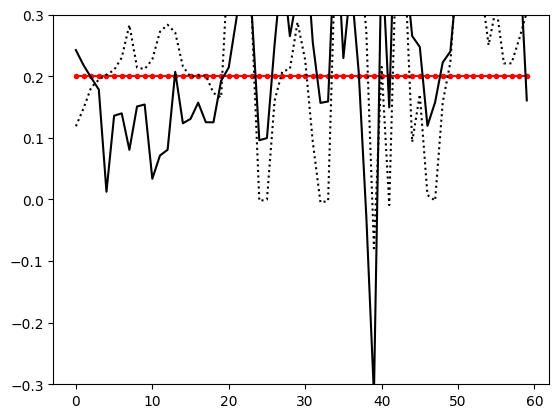

step: 10 0.6001624999999999
step: 11 0.6001624999999999
step: 12 0.6001624999999999


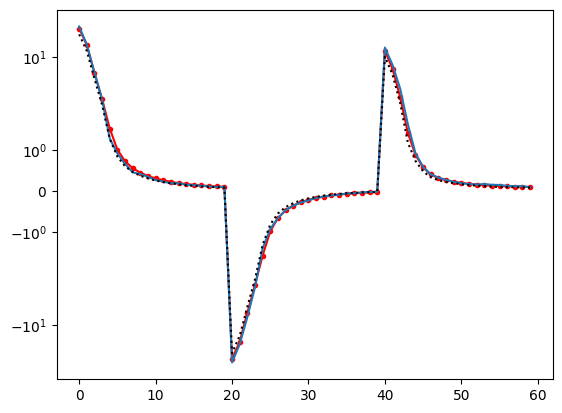

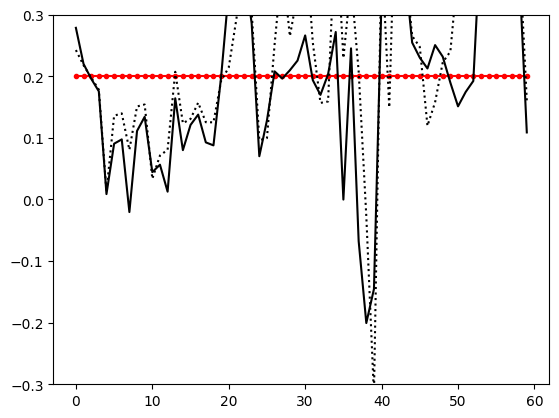

step: 13 0.5701543749999999
step: 14 0.5701543749999999
step: 15 0.5701543749999999


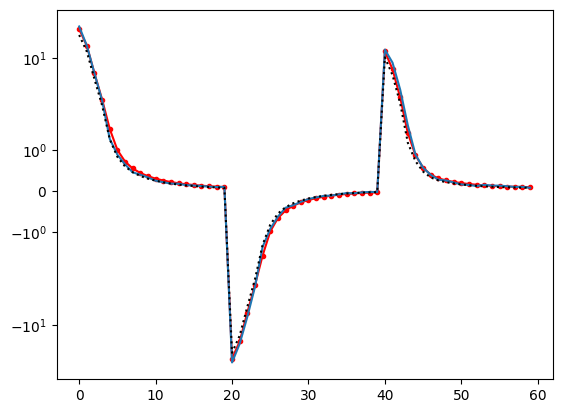

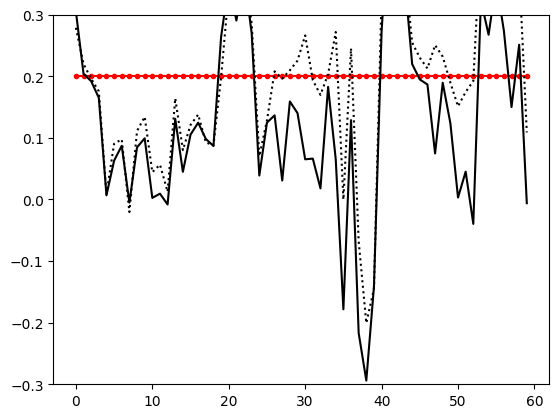

step: 16 0.5416466562499999
step: 17 0.5416466562499999
step: 18 0.5416466562499999


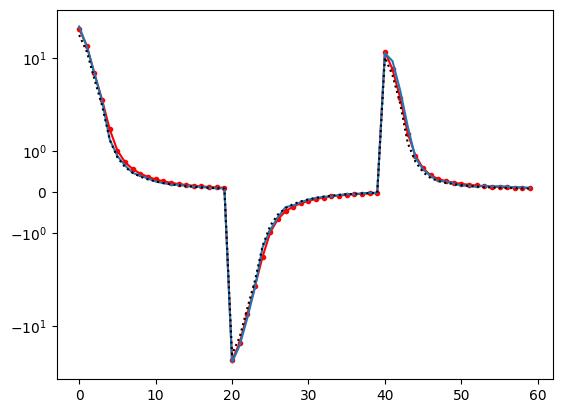

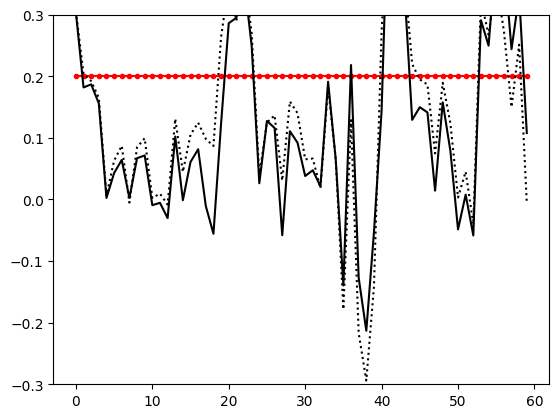

step: 19 0.5145643234374998
step: 20 0.5145643234374998
step: 21 0.5145643234374998


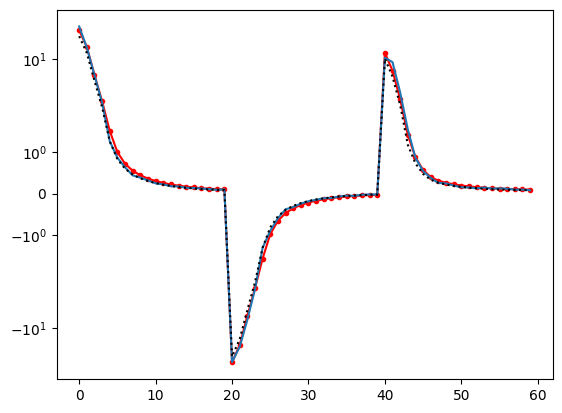

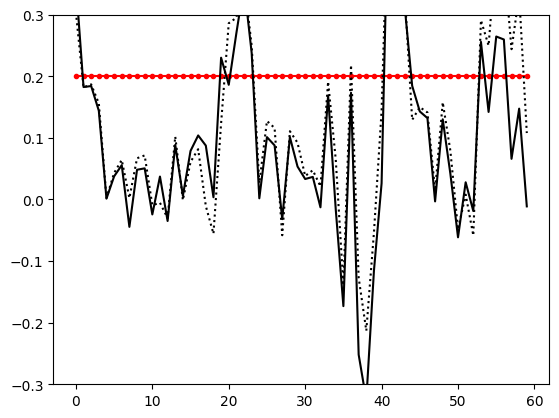

step: 22 0.48883610726562476
step: 23 0.48883610726562476
step: 24 0.48883610726562476


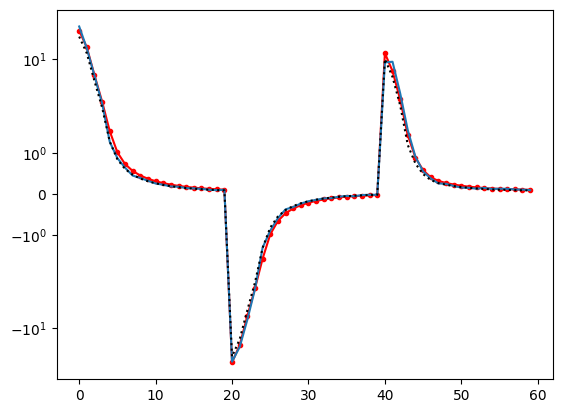

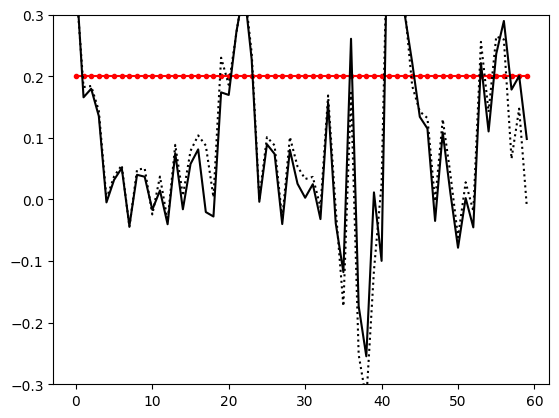

step: 25 0.4643943019023435
step: 26 0.4643943019023435
step: 27 0.4643943019023435


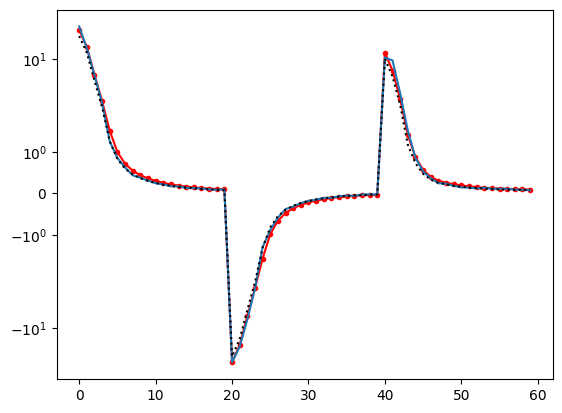

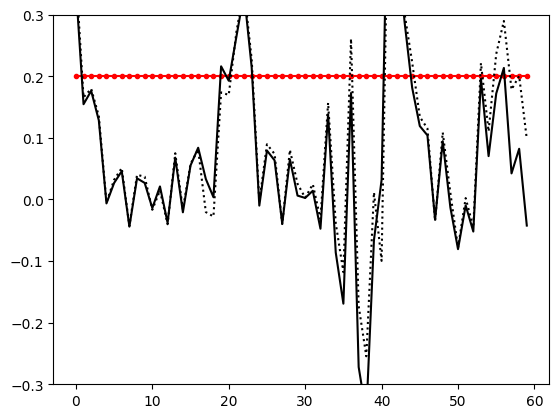

step: 28 0.44117458680722627
step: 29 0.44117458680722627
step: 30 0.44117458680722627


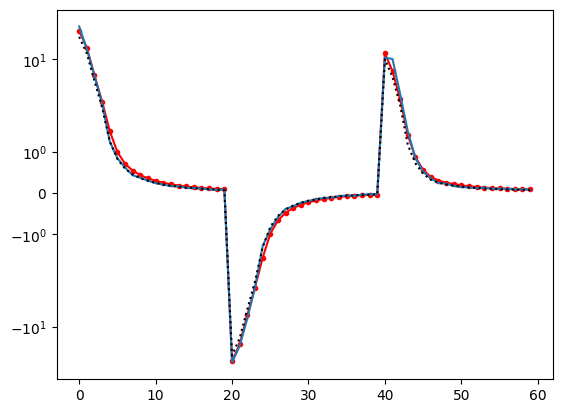

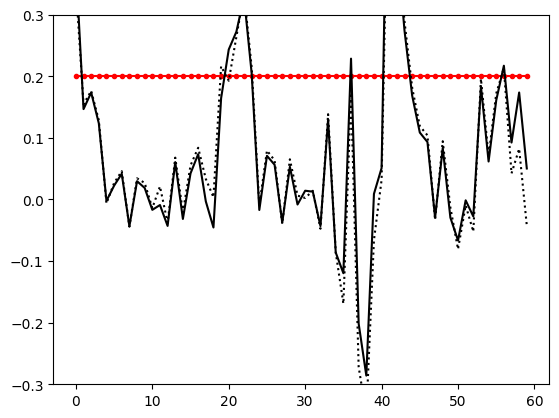

step: 31 0.4191158574668649
step: 32 0.4191158574668649
step: 33 0.4191158574668649


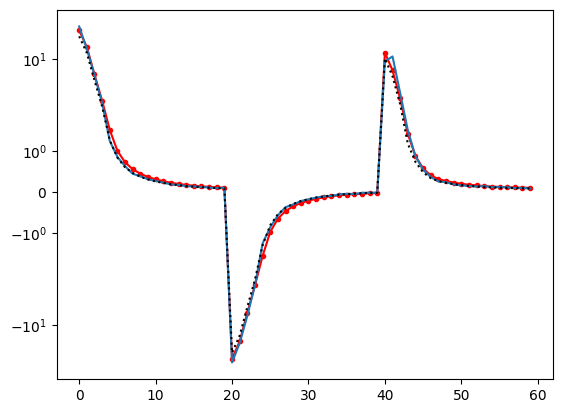

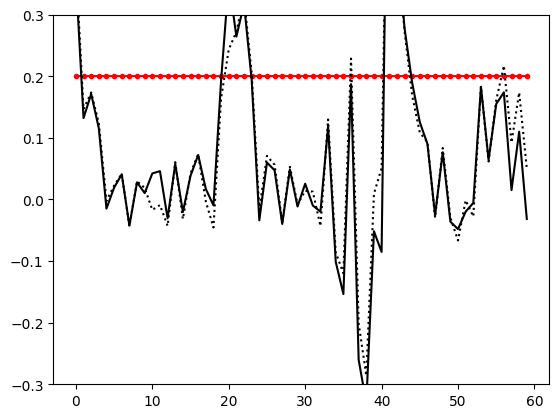

step: 34 0.39816006459352166
step: 35 0.39816006459352166
step: 36 0.39816006459352166


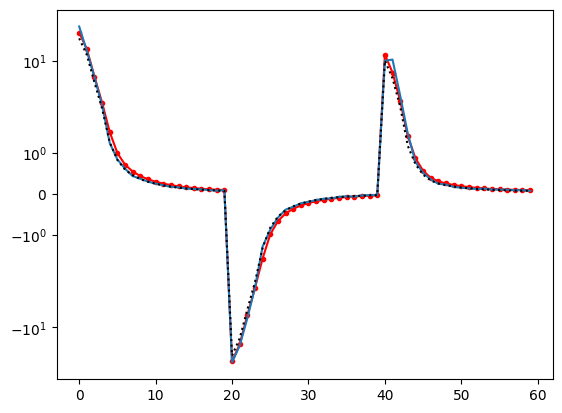

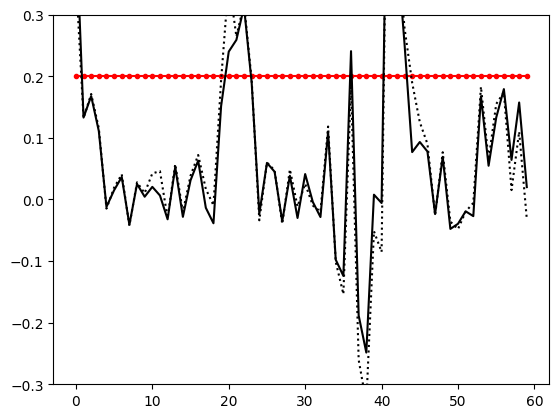

step: 37 0.37825206136384554
step: 38 0.37825206136384554
step: 39 0.37825206136384554


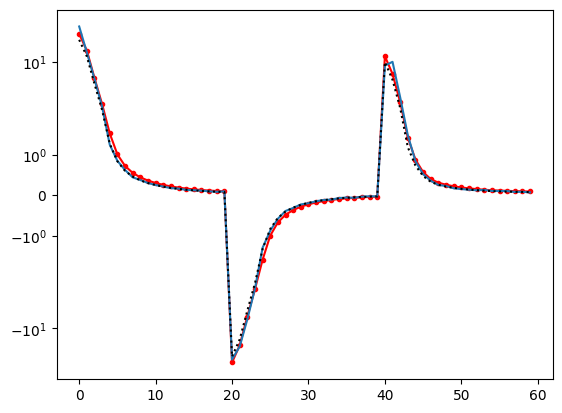

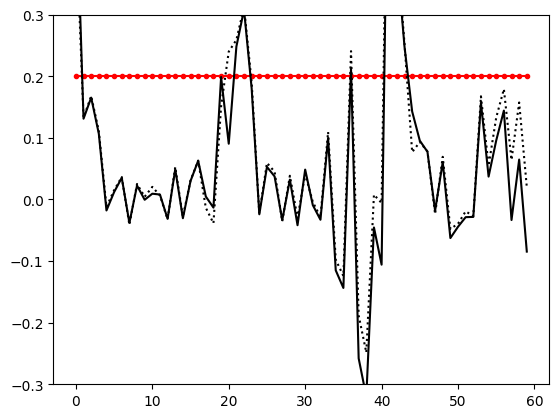

step: 40 0.3593394582956532
step: 41 0.3593394582956532
step: 42 0.3593394582956532


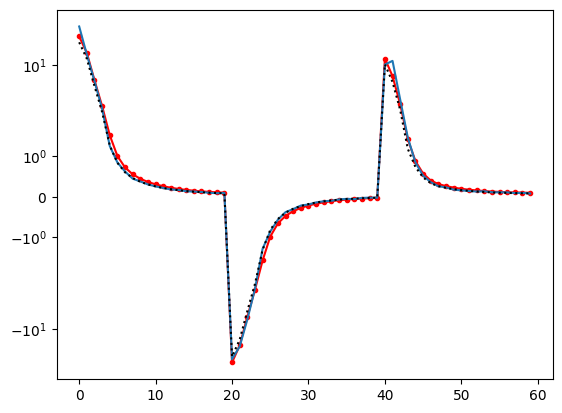

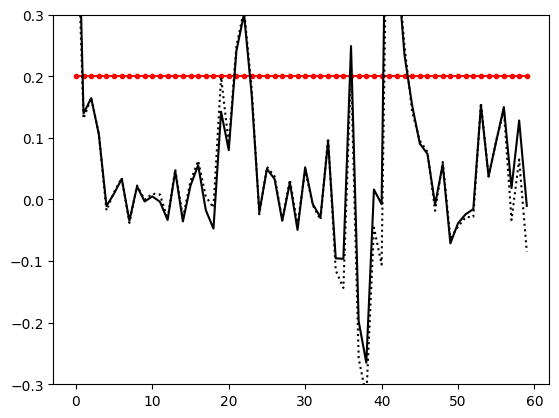

step: 43 0.34137248538087056
step: 44 0.34137248538087056
step: 45 0.34137248538087056


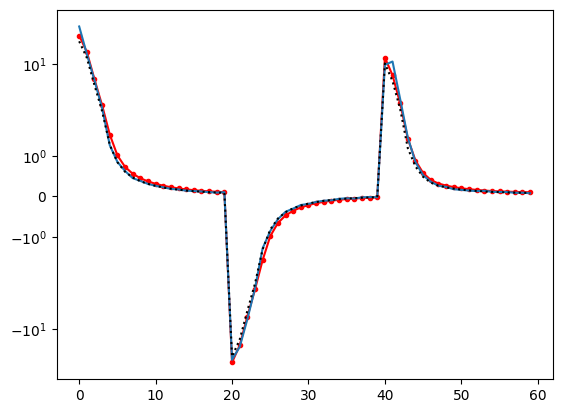

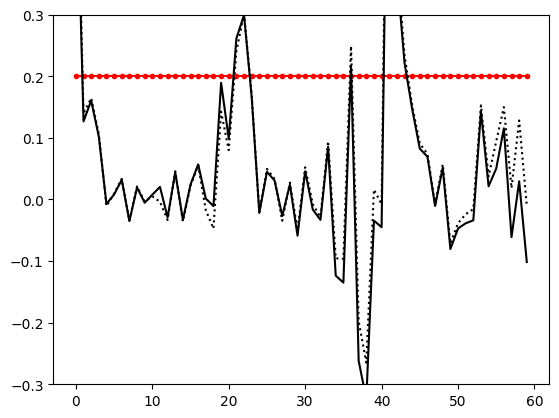

step: 46 0.324303861111827
step: 47 0.324303861111827
step: 48 0.324303861111827


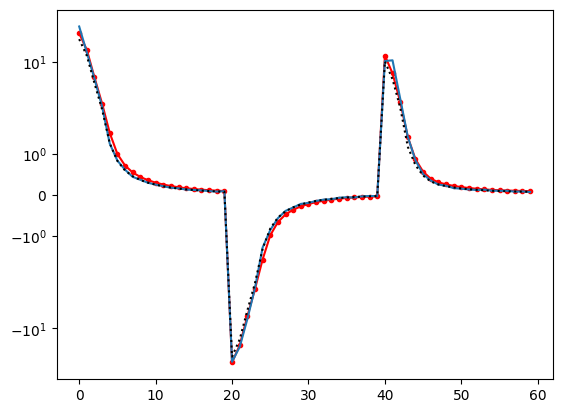

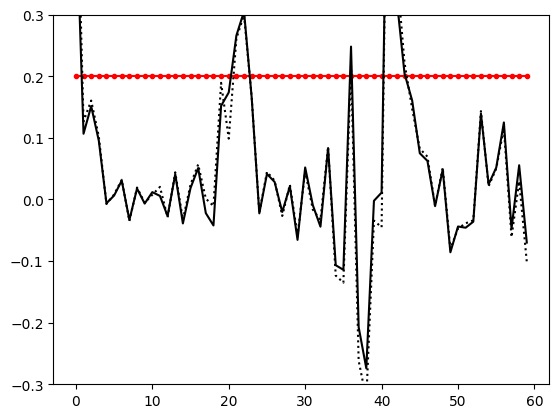

step: 49 0.30808866805623564
step: 50 0.30808866805623564
step: 51 0.30808866805623564


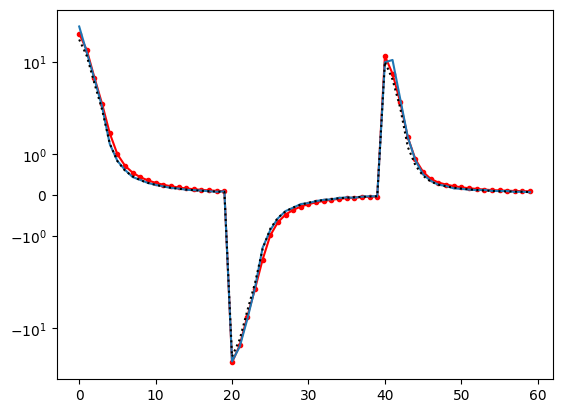

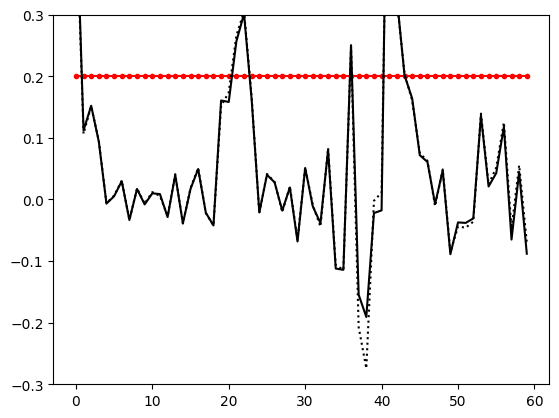

step: 52 0.29268423465342386
step: 53 0.29268423465342386
step: 54 0.29268423465342386


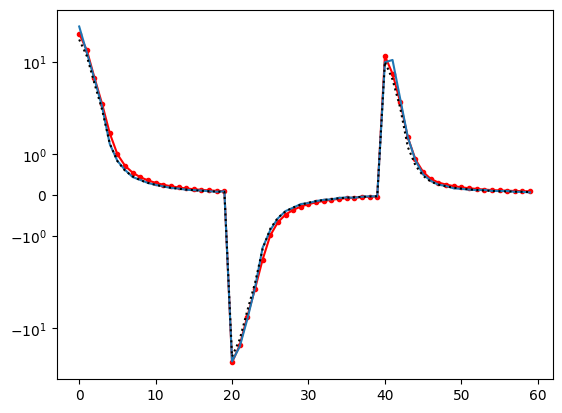

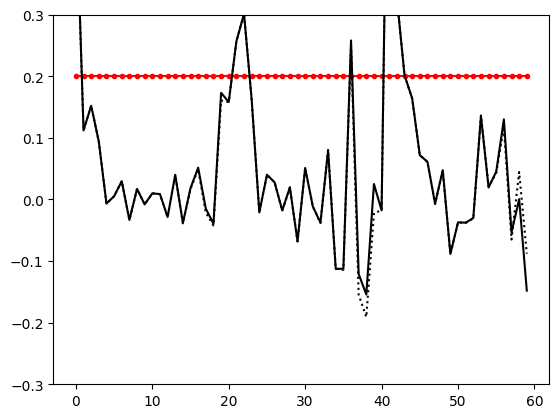

step: 55 0.27805002292075265
step: 56 0.27805002292075265
step: 57 0.27805002292075265


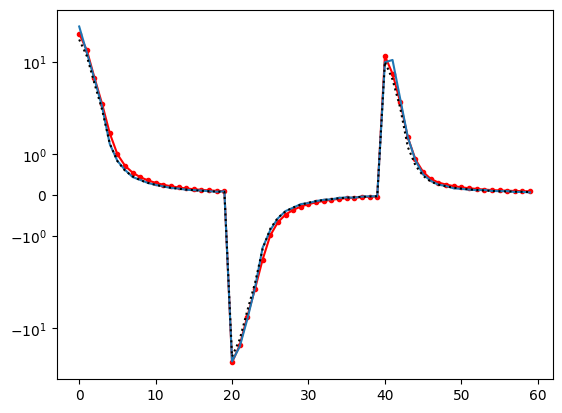

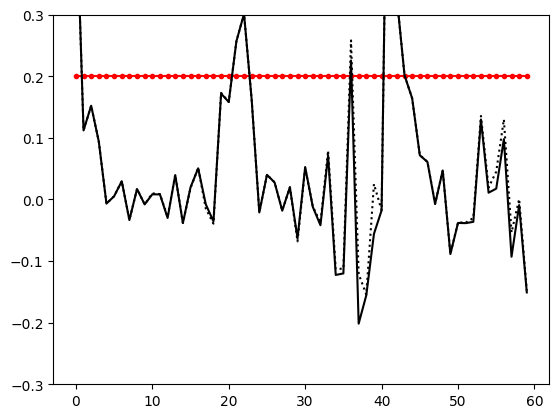

step: 58 0.264147521774715
step: 59 0.264147521774715
step: 60 0.264147521774715


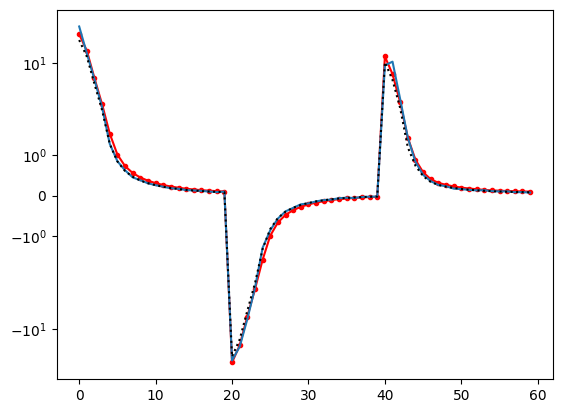

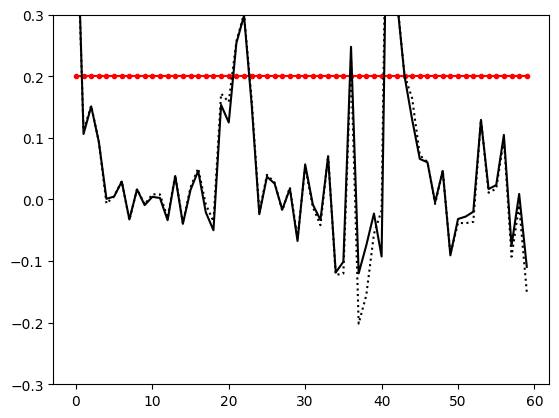

step: 61 0.2509401456859792
step: 62 0.2509401456859792
step: 63 0.2509401456859792


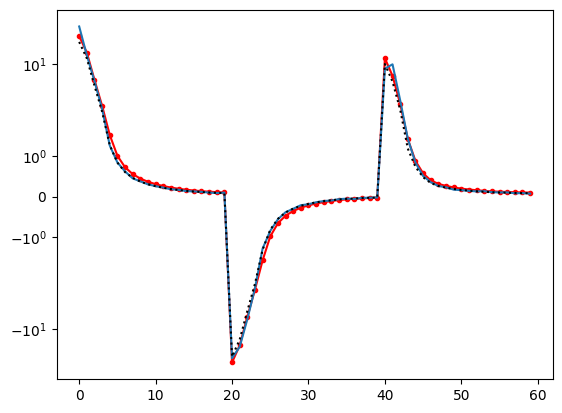

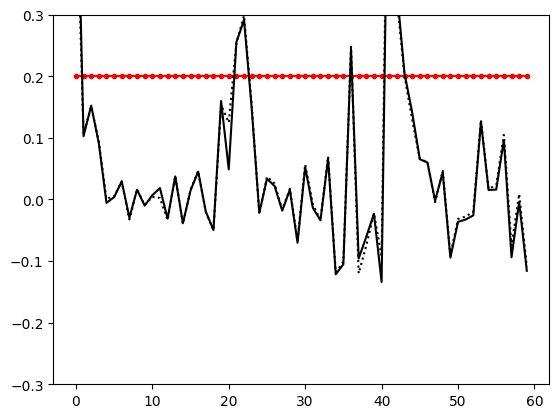

step: 64 0.23839313840168025
step: 65 0.23839313840168025
step: 66 0.23839313840168025


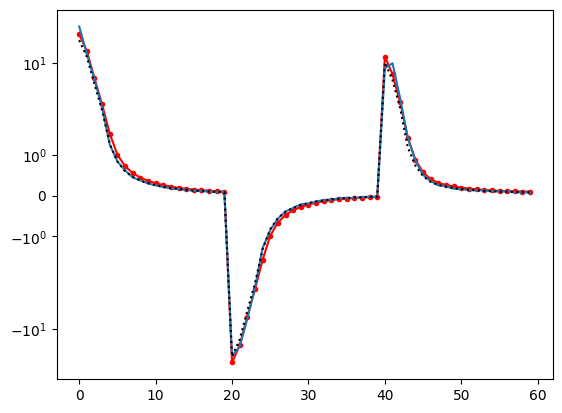

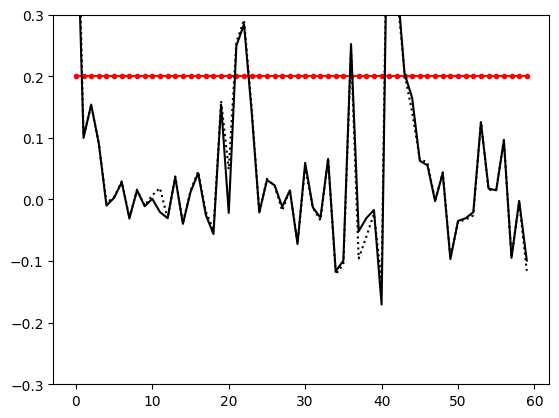

step: 67 0.22647348148159624
step: 68 0.22647348148159624
step: 69 0.22647348148159624


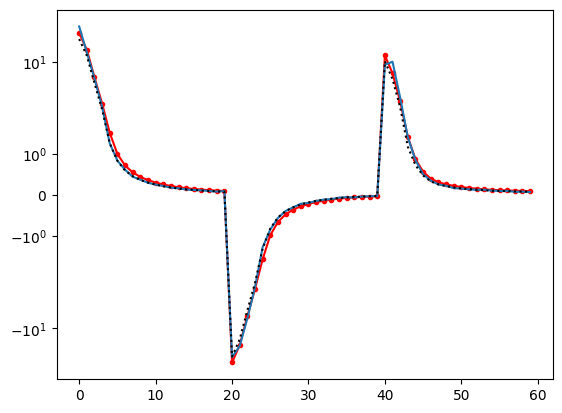

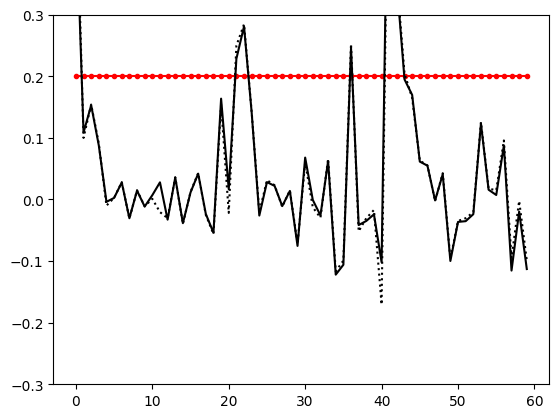

step: 70 0.2151498074075164
step: 71 0.2151498074075164
step: 72 0.2151498074075164


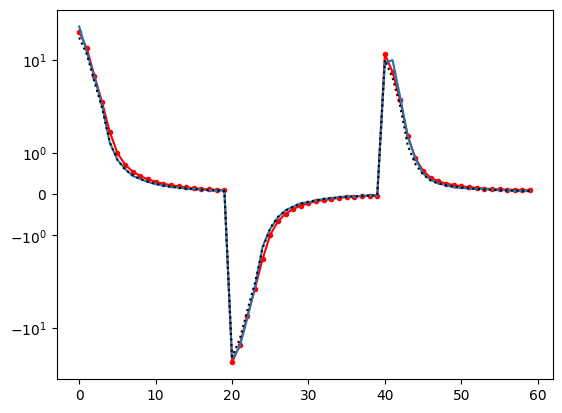

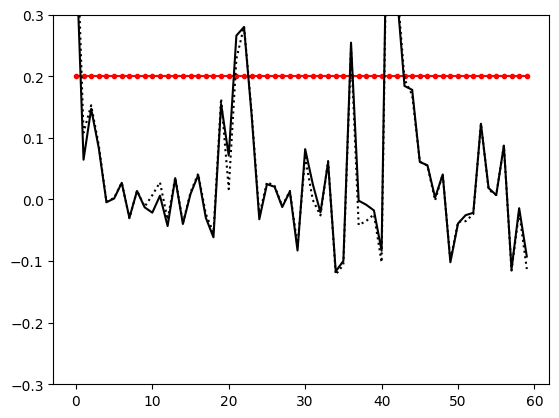

step: 73 0.2043923170371406
step: 74 0.2043923170371406
step: 75 0.2043923170371406


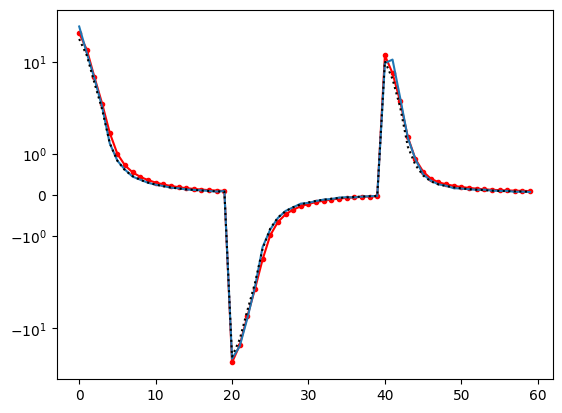

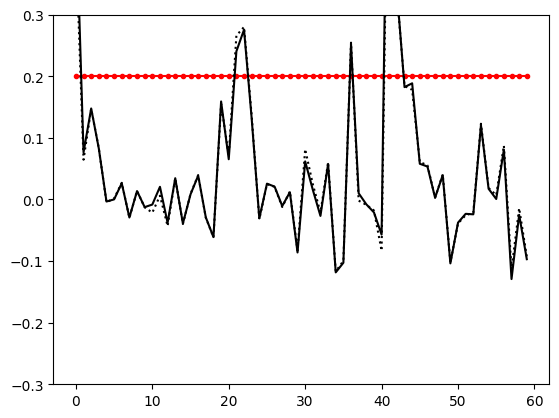

step: 76 0.19417270118528354
step: 77 0.19417270118528354
step: 78 0.19417270118528354


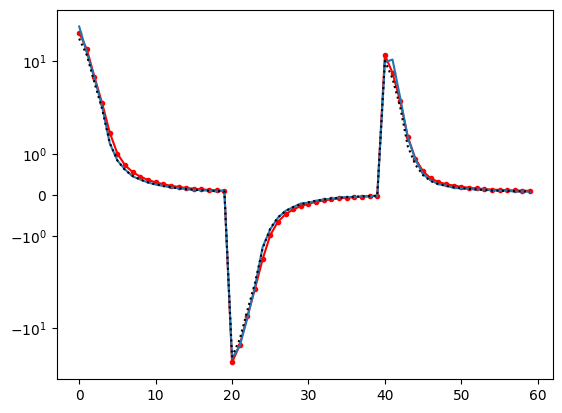

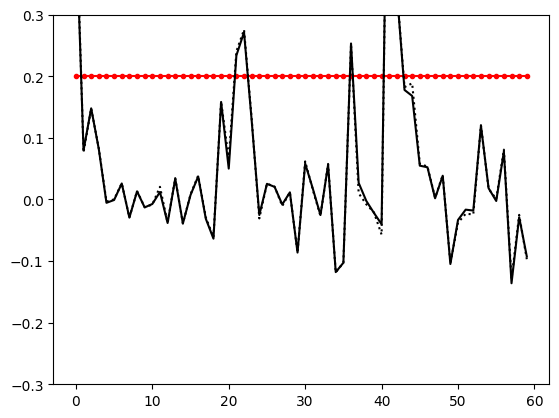

step: 79 0.18446406612601934
step: 80 0.18446406612601934
step: 81 0.18446406612601934


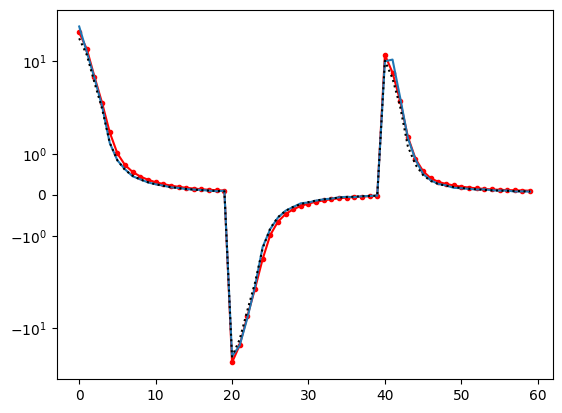

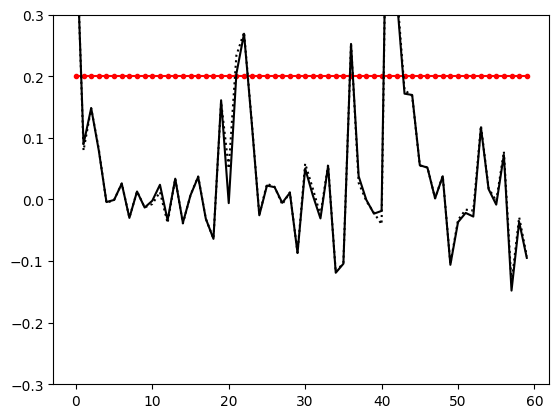

step: 82 0.17524086281971837
step: 83 0.17524086281971837
step: 84 0.17524086281971837


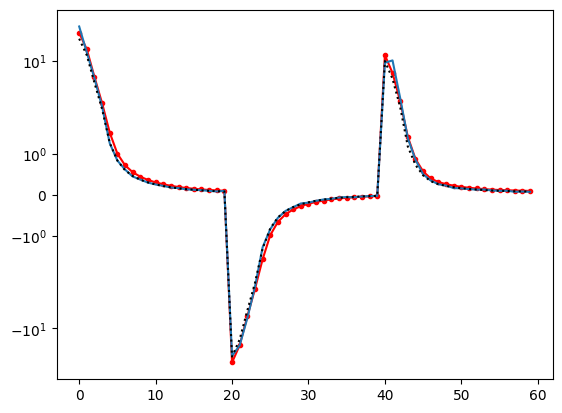

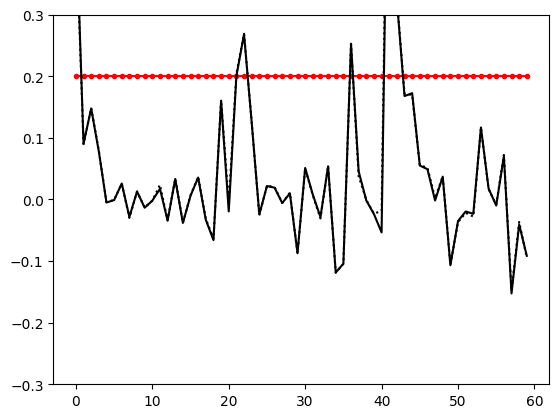

step: 85 0.16647881967873246
step: 86 0.16647881967873246
step: 87 0.16647881967873246


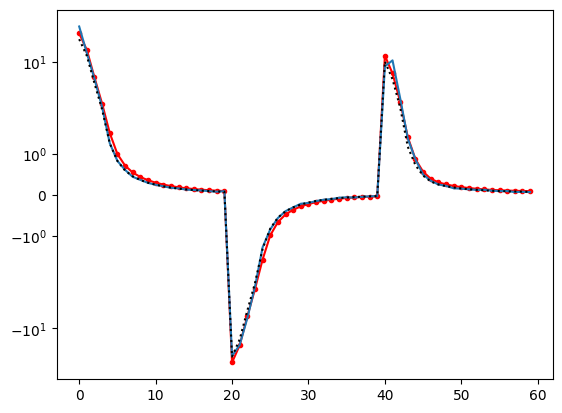

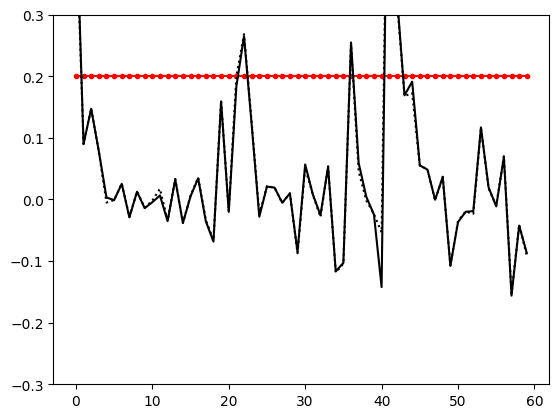

step: 88 0.15815487869479583
step: 89 0.15815487869479583
step: 90 0.15815487869479583


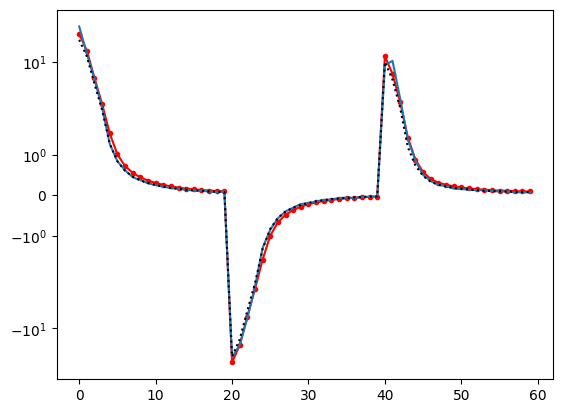

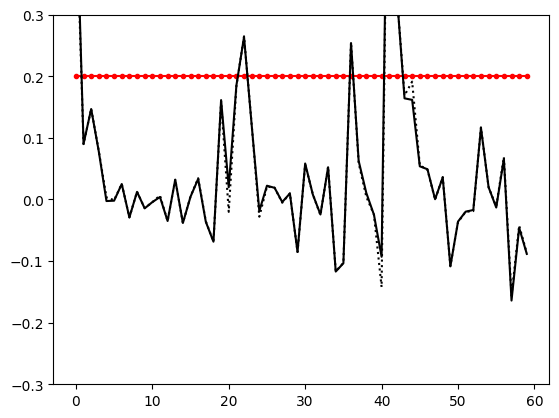

step: 91 0.15024713476005602
step: 92 0.15024713476005602
step: 93 0.15024713476005602


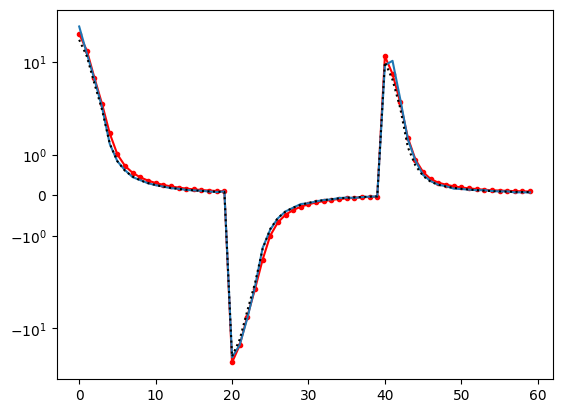

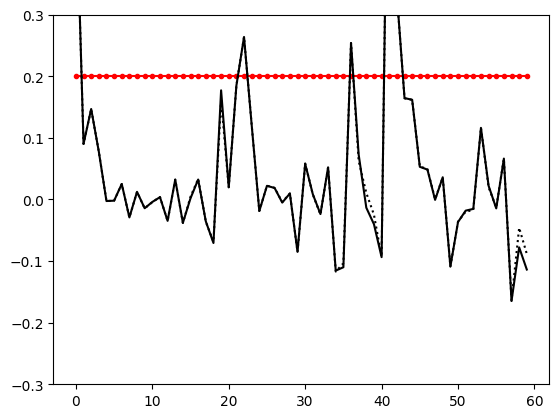

step: 94 0.14273477802205323
step: 95 0.14273477802205323
step: 96 0.14273477802205323


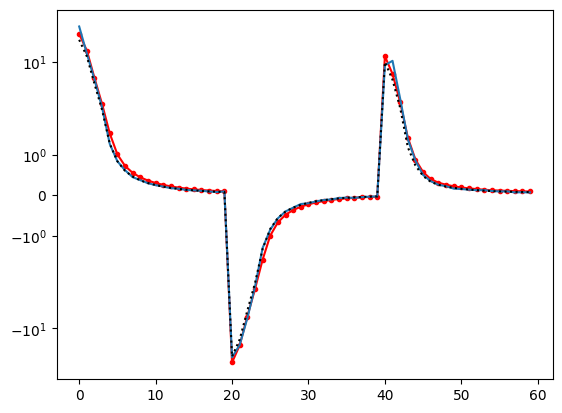

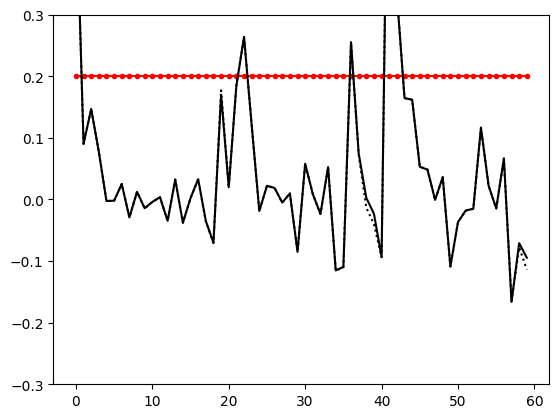

step: 97 0.13559803912095056
step: 98 0.13559803912095056
step: 99 0.13559803912095056


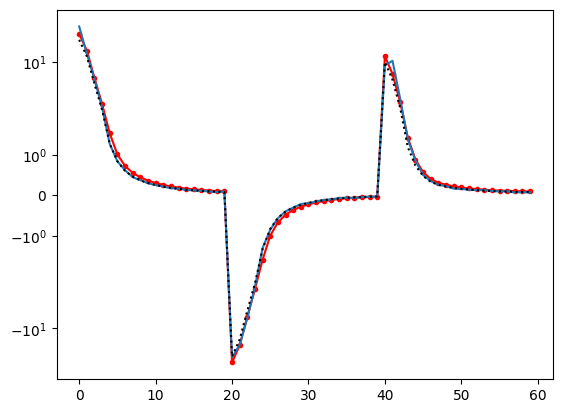

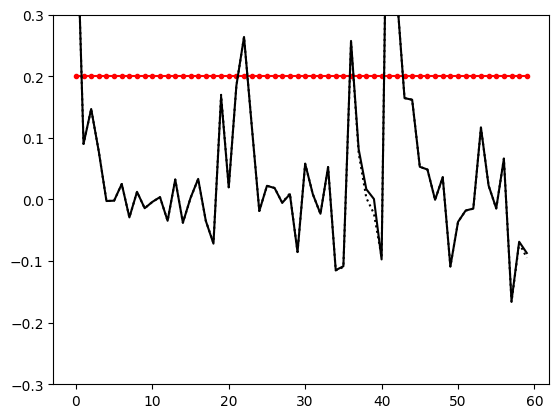

step: 100 0.12881813716490303
step: 101 0.12881813716490303
step: 102 0.12881813716490303


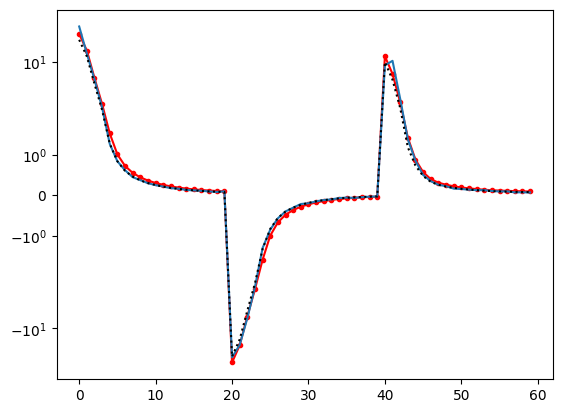

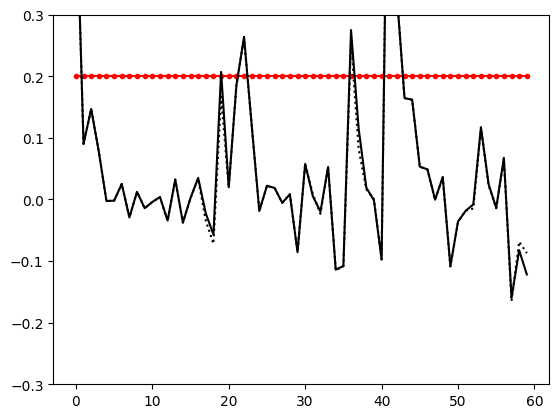

step: 103 0.12237723030665788
step: 104 0.12237723030665788
step: 105 0.12237723030665788


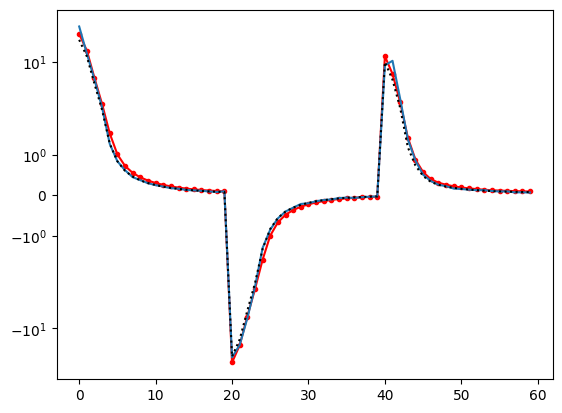

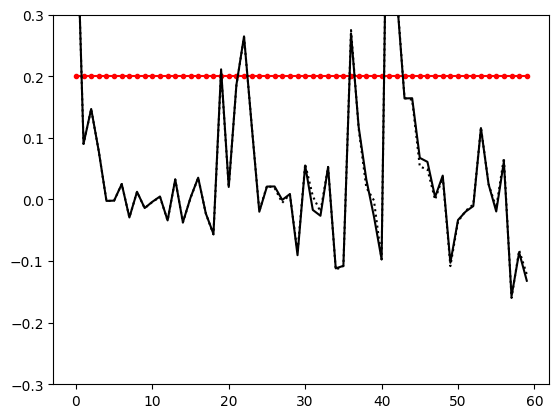

step: 106 0.11625836879132498
step: 107 0.11625836879132498
step: 108 0.11625836879132498


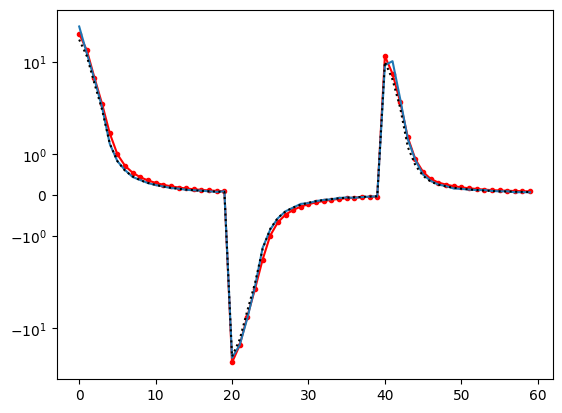

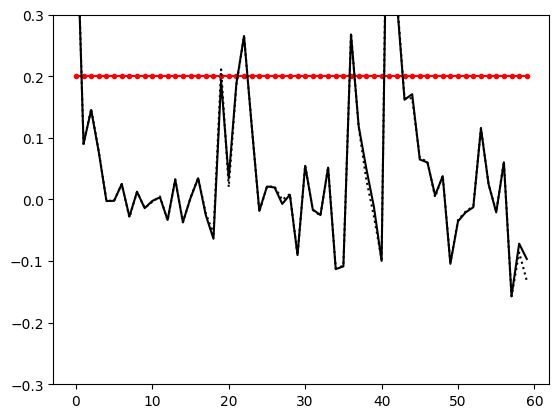

step: 109 0.11044545035175872
step: 110 0.11044545035175872
step: 111 0.11044545035175872


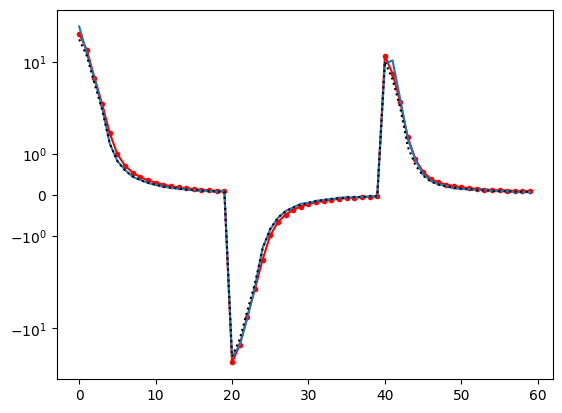

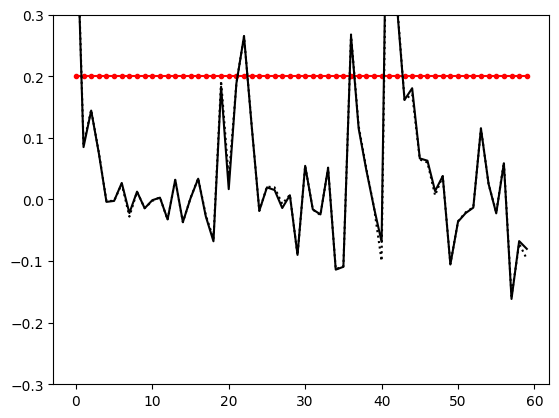

step: 112 0.10492317783417078
step: 113 0.10492317783417078
step: 114 0.10492317783417078


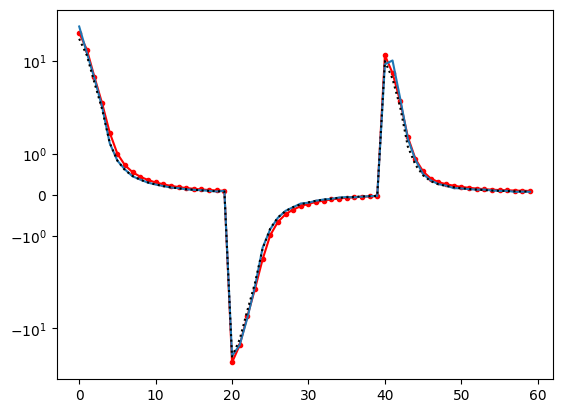

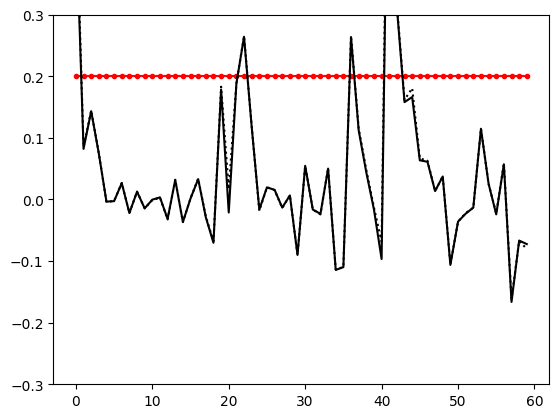

step: 115 0.09967701894246224
step: 116 0.09967701894246224
step: 117 0.09967701894246224


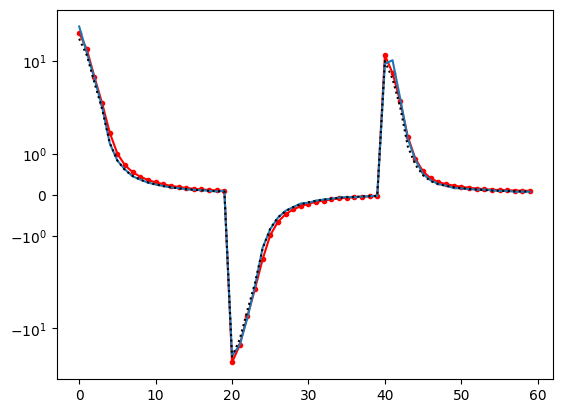

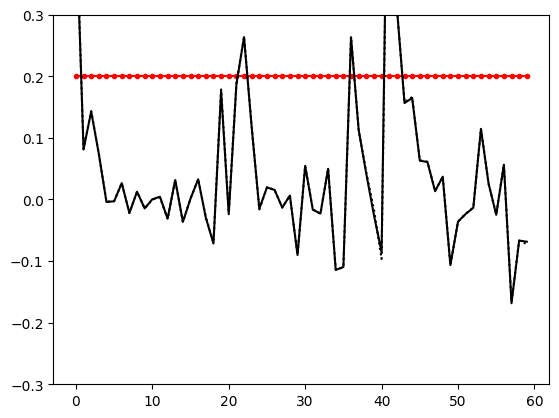

step: 118 0.09469316799533913
step: 119 0.09469316799533913
step: 120 0.09469316799533913


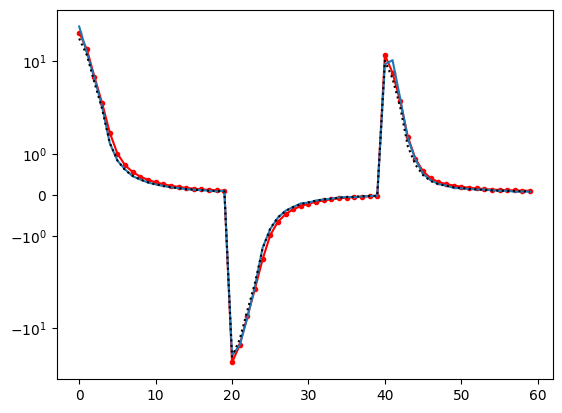

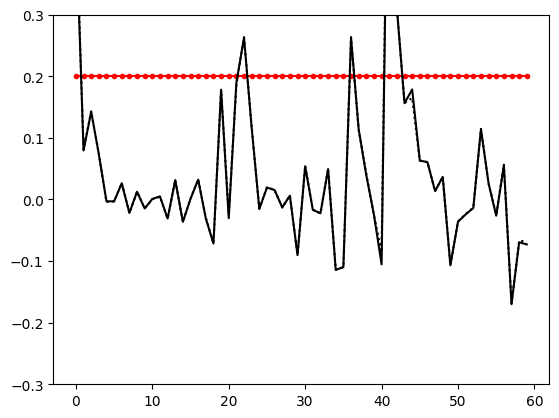

step: 121 0.08995850959557217
step: 122 0.08995850959557217
step: 123 0.08995850959557217


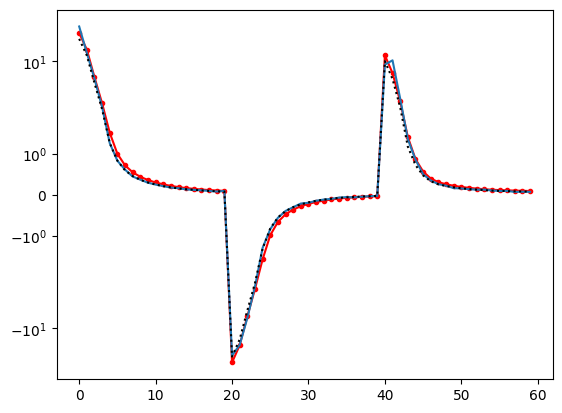

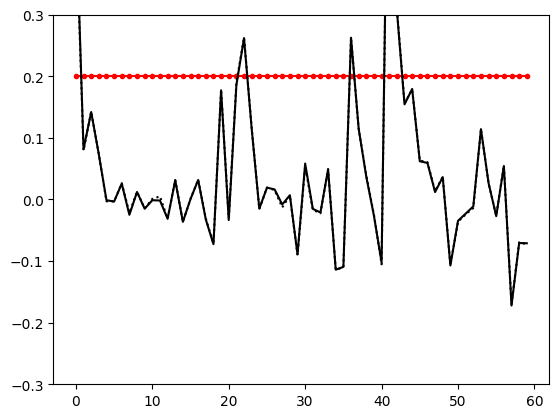

step: 124 0.08546058411579356
step: 125 0.08546058411579356
step: 126 0.08546058411579356


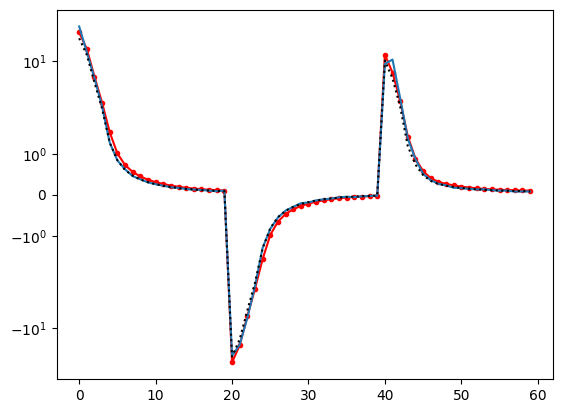

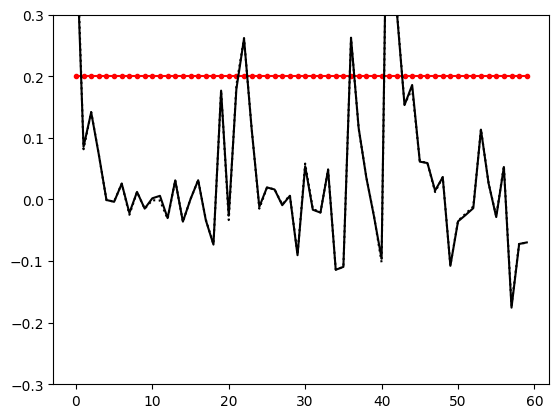

step: 127 0.08118755491000387
step: 128 0.08118755491000387
step: 129 0.08118755491000387


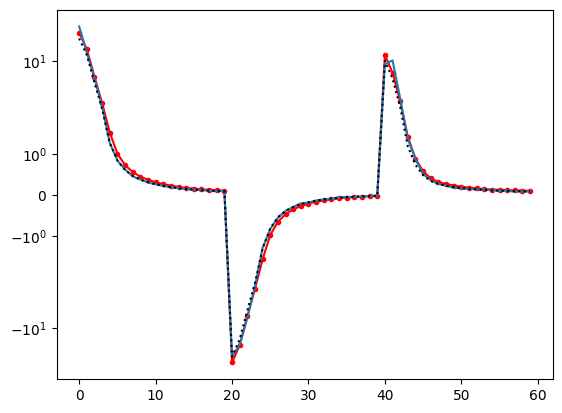

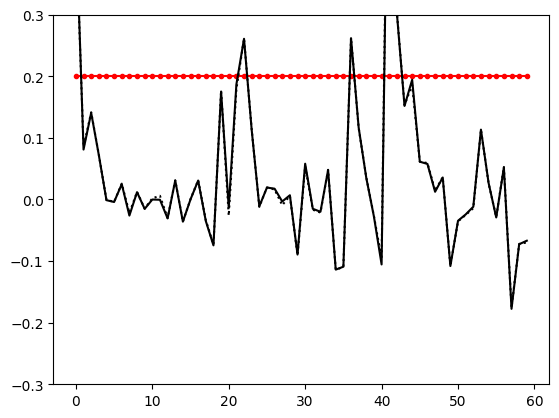

step: 130 0.07712817716450368
step: 131 0.07712817716450368
step: 132 0.07712817716450368


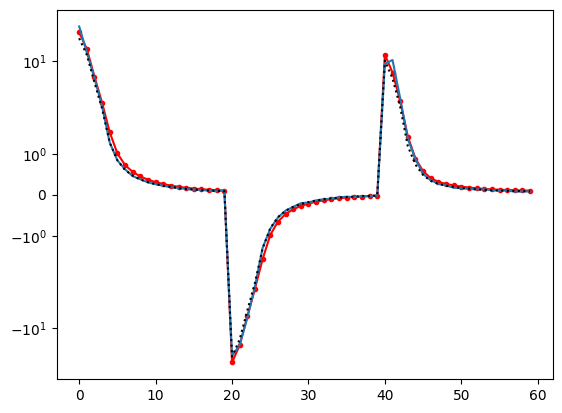

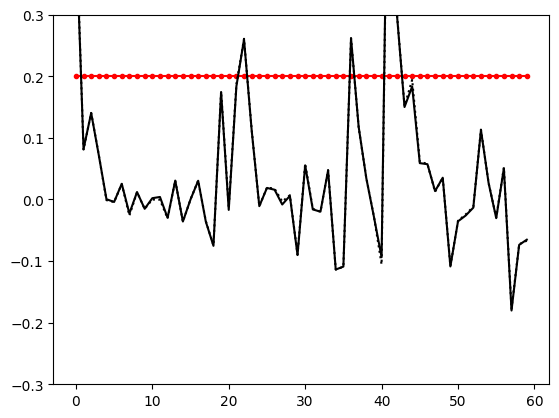

step: 133 0.07327176830627849
step: 134 0.07327176830627849
step: 135 0.07327176830627849


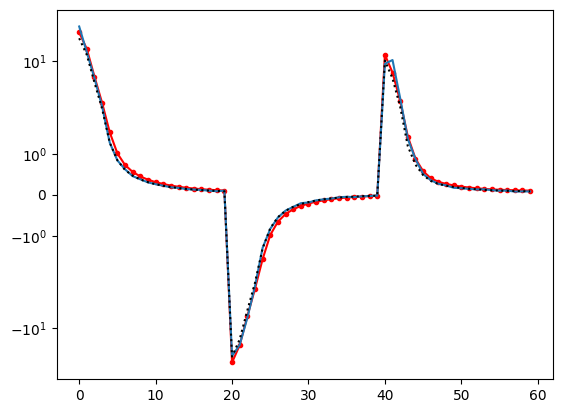

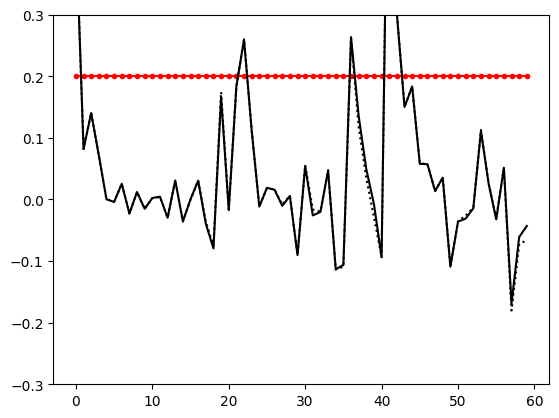

step: 136 0.06960817989096456
step: 137 0.06960817989096456
step: 138 0.06960817989096456


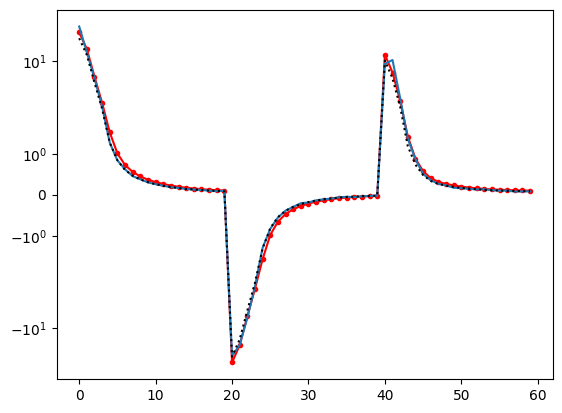

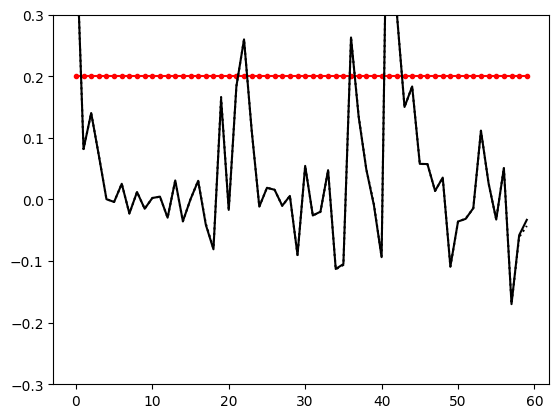

step: 139 0.06612777089641633
step: 140 0.06612777089641633
step: 141 0.06612777089641633


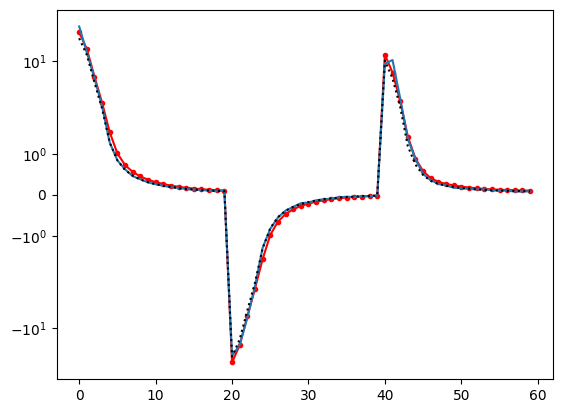

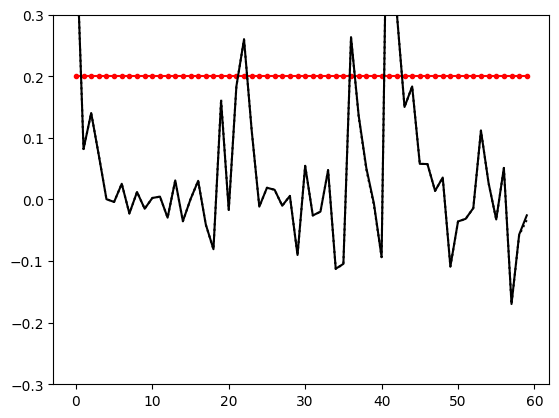

step: 142 0.06282138235159551
step: 143 0.06282138235159551
step: 144 0.06282138235159551


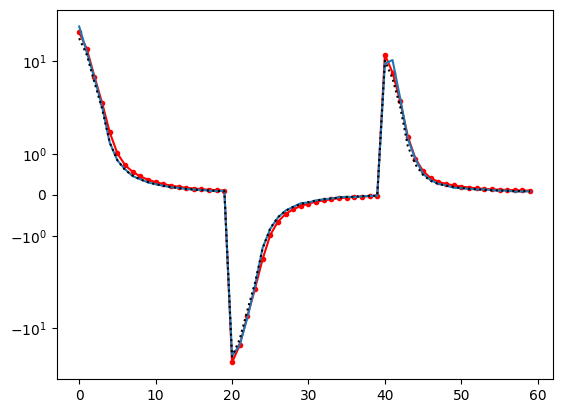

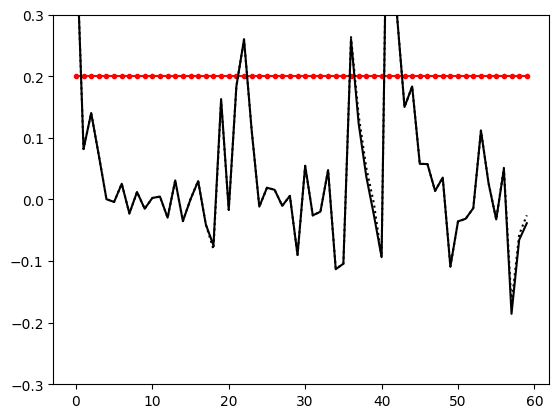

step: 145 0.059680313234015736
step: 146 0.059680313234015736
step: 147 0.059680313234015736


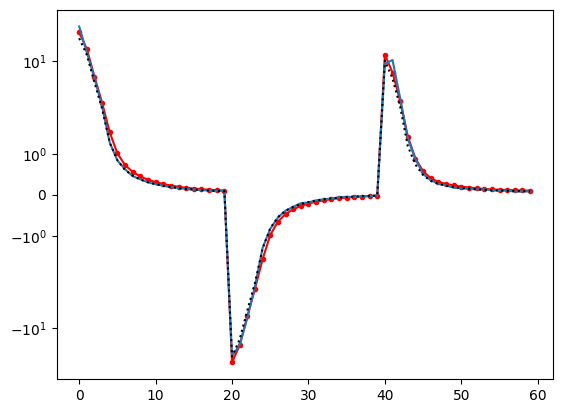

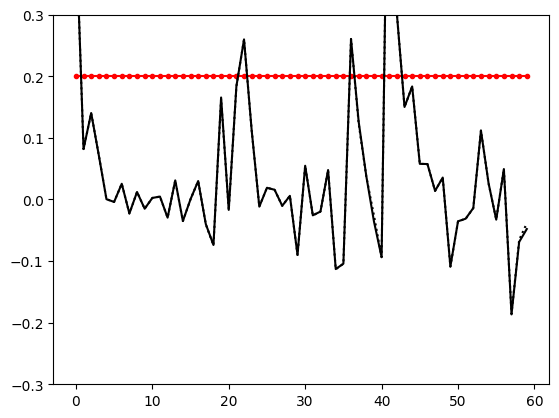

step: 148 0.056696297572314945
step: 149 0.056696297572314945
step: 150 0.056696297572314945


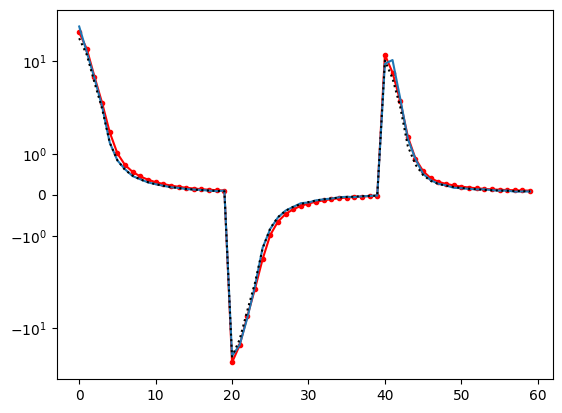

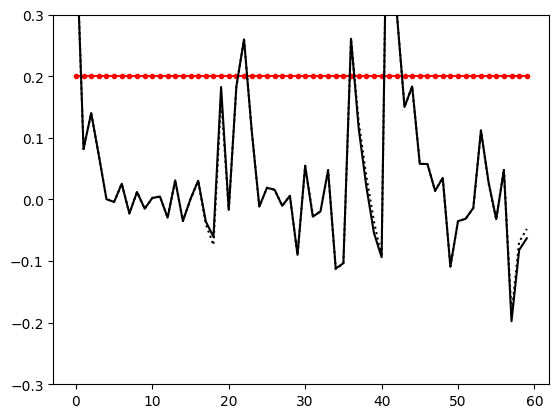

step: 151 0.475
step: 152 0.475
step: 153 0.475


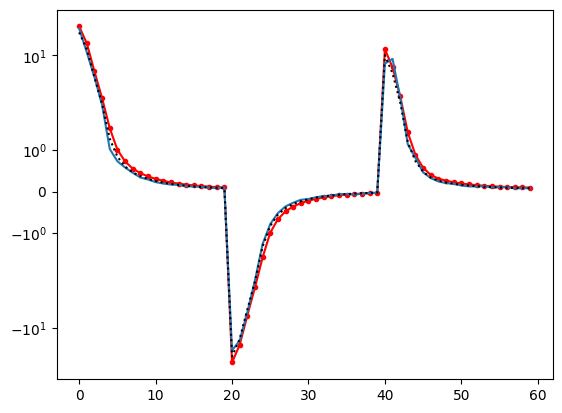

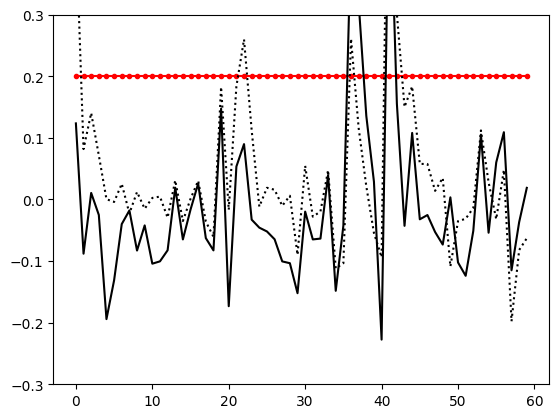

step: 154 0.45125
step: 155 0.45125
step: 156 0.45125


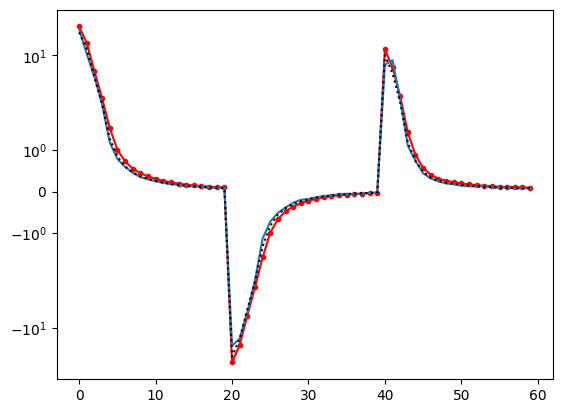

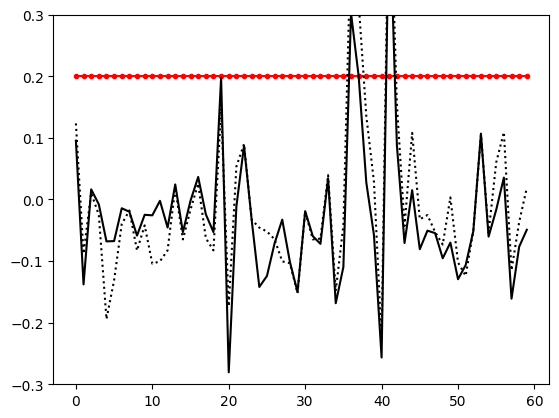

step: 157 0.42868749999999994
step: 158 0.42868749999999994
step: 159 0.42868749999999994


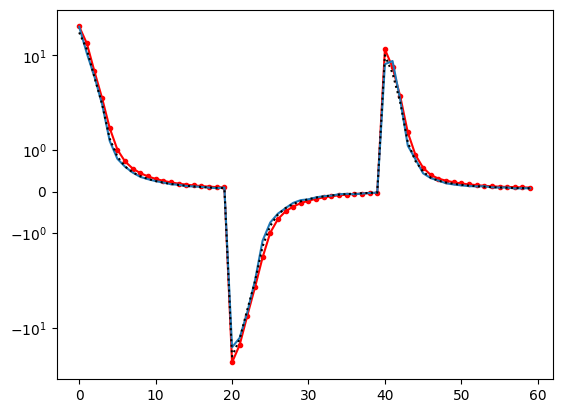

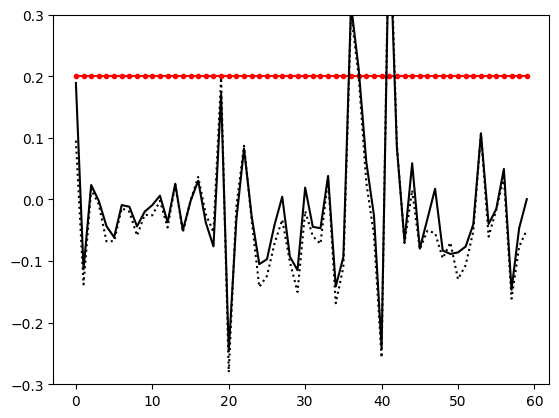

step: 160 0.40725312499999994
step: 161 0.40725312499999994
step: 162 0.40725312499999994


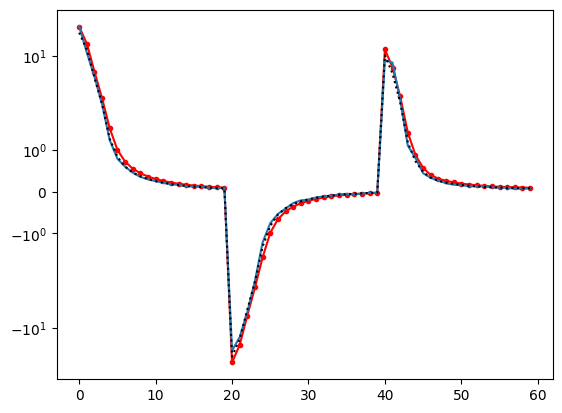

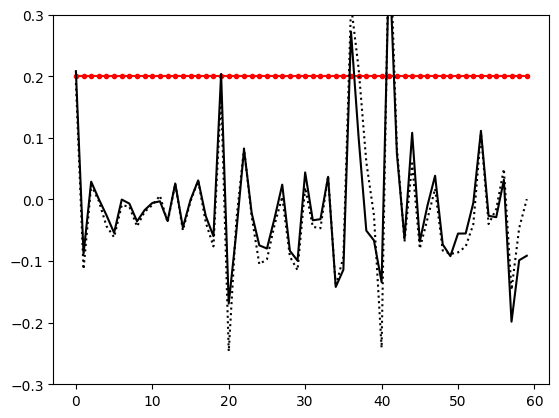

step: 163 0.38689046874999994
step: 164 0.38689046874999994
step: 165 0.38689046874999994


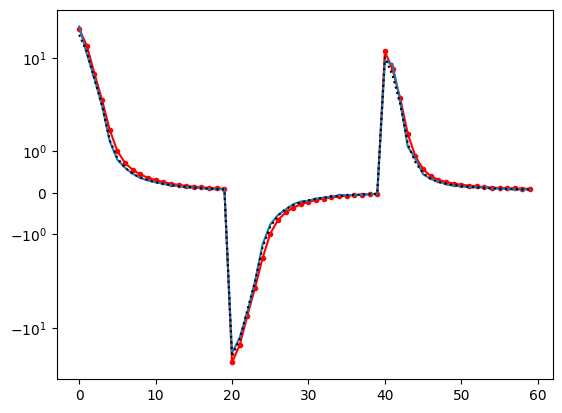

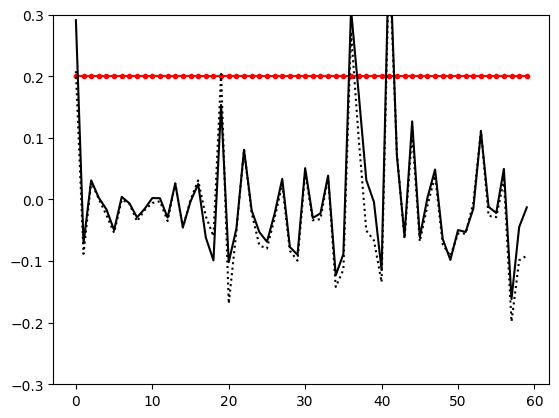

step: 166 0.3675459453124999
step: 167 0.3675459453124999
step: 168 0.3675459453124999


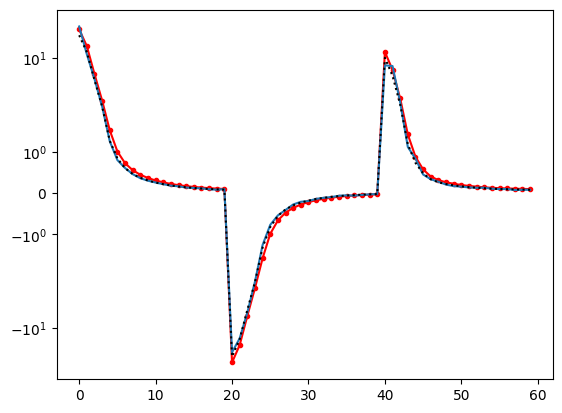

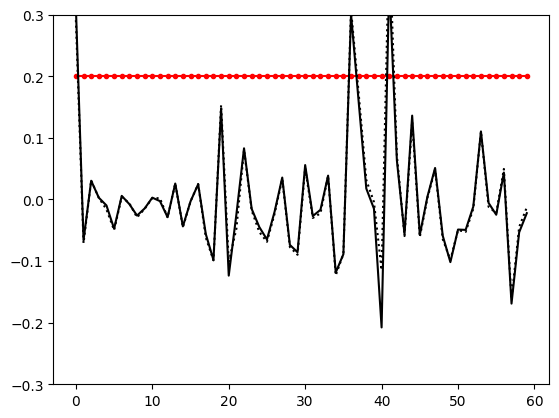

step: 169 0.34916864804687486
step: 170 0.34916864804687486
step: 171 0.34916864804687486


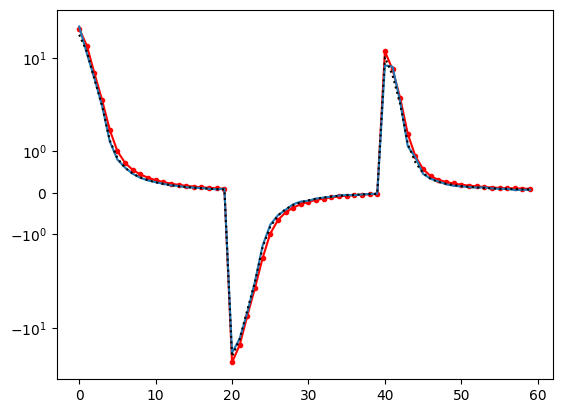

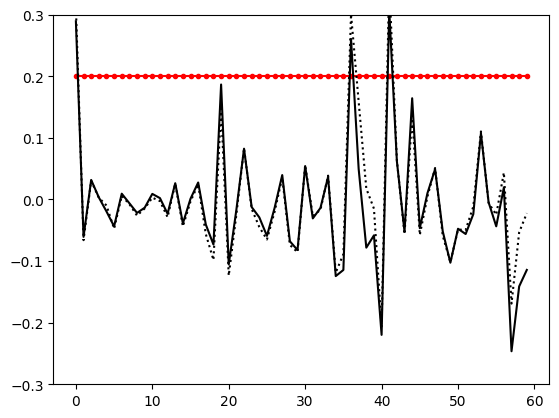

step: 172 0.3317102156445311
step: 173 0.3317102156445311
step: 174 0.3317102156445311


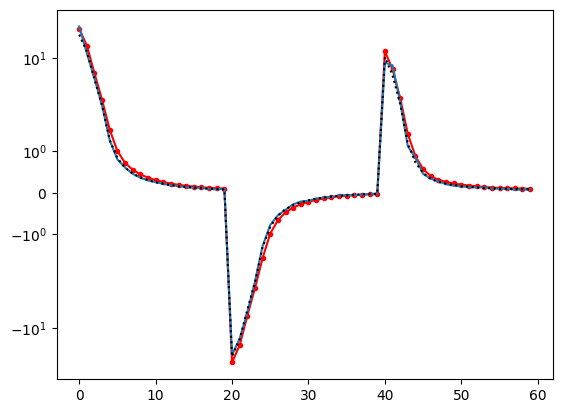

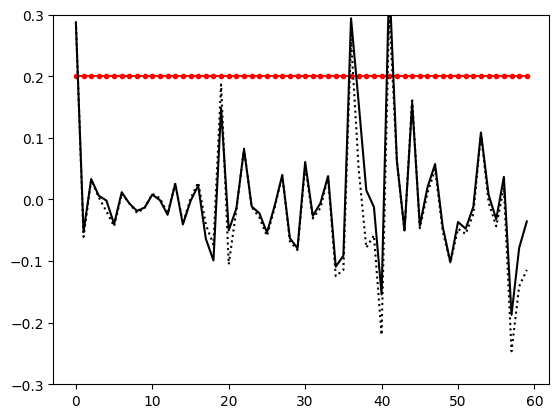

step: 175 0.31512470486230454
step: 176 0.31512470486230454
step: 177 0.31512470486230454


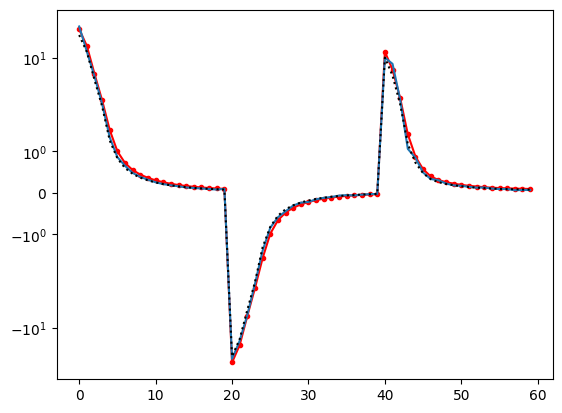

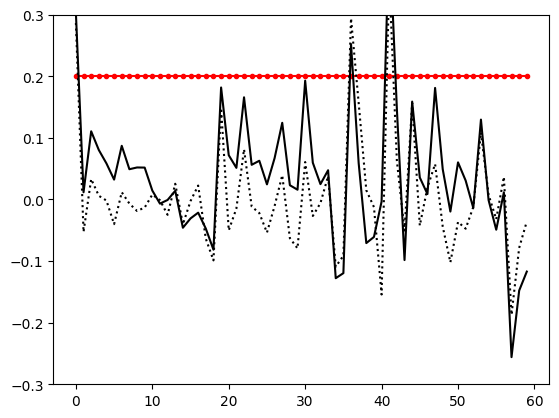

step: 178 0.2993684696191893
step: 179 0.2993684696191893
step: 180 0.2993684696191893


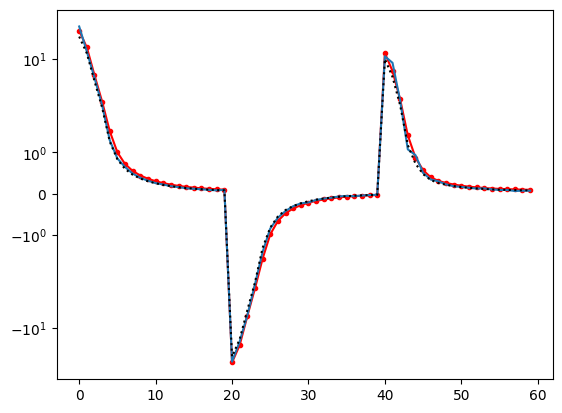

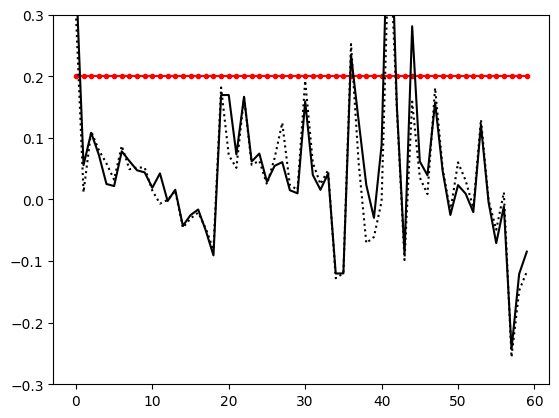

step: 181 0.2844000461382298
step: 182 0.2844000461382298
step: 183 0.2844000461382298


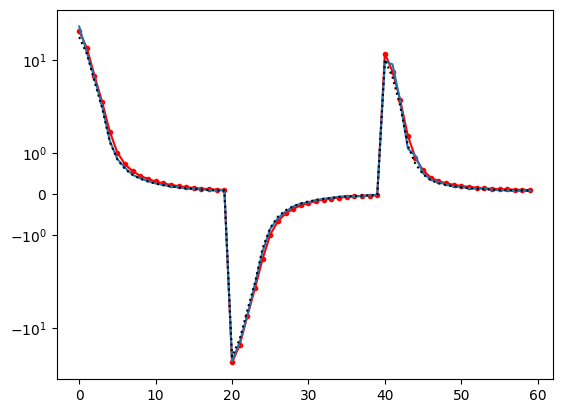

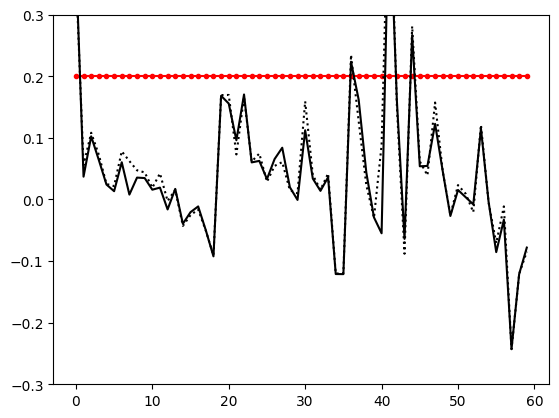

step: 184 0.2701800438313183
step: 185 0.2701800438313183
step: 186 0.2701800438313183


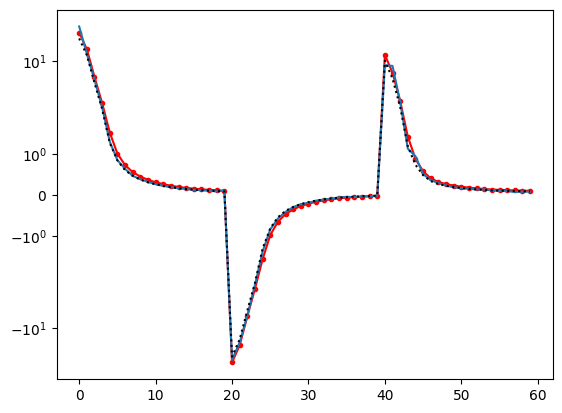

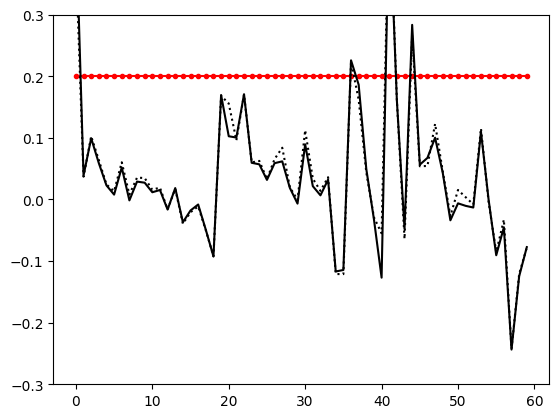

step: 187 0.25667104163975235
step: 188 0.25667104163975235
step: 189 0.25667104163975235


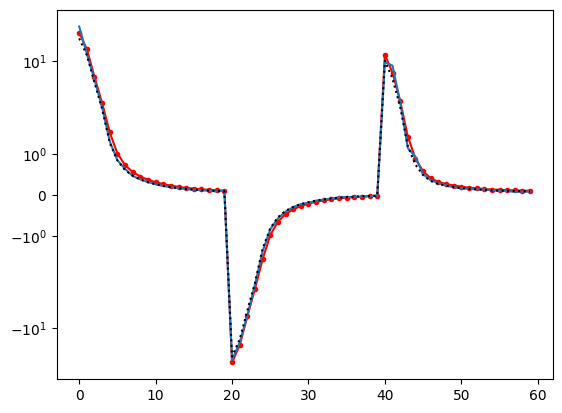

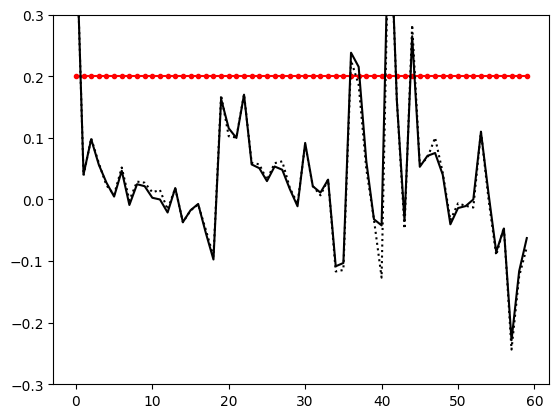

step: 190 0.24383748955776471
step: 191 0.24383748955776471
step: 192 0.24383748955776471


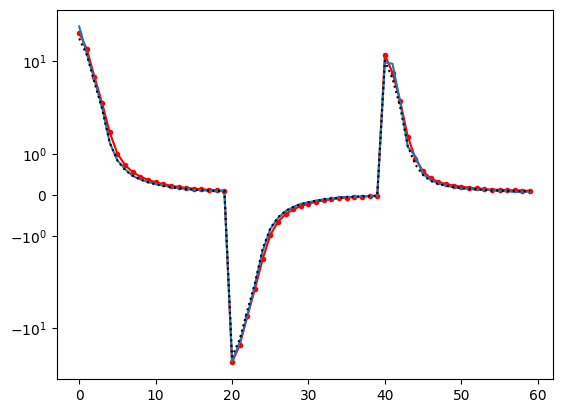

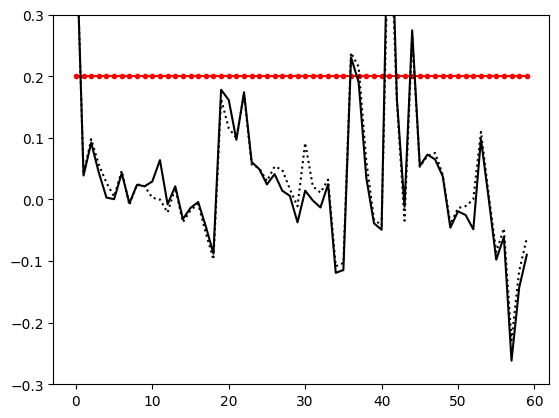

step: 193 0.23164561507987647
step: 194 0.23164561507987647
step: 195 0.23164561507987647


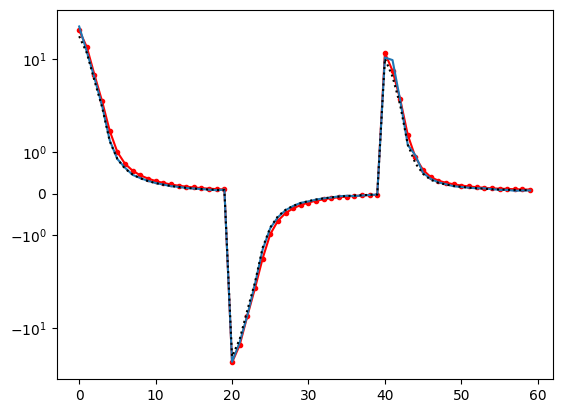

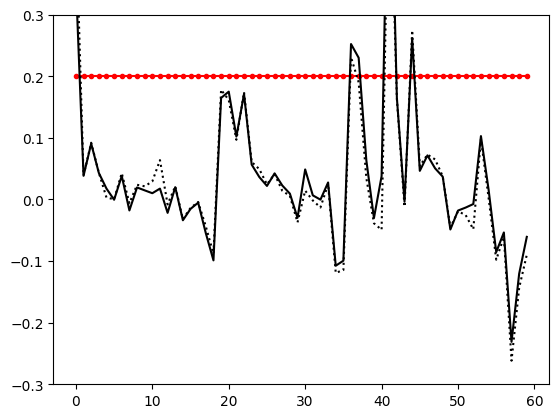

step: 196 0.22006333432588263
step: 197 0.22006333432588263
step: 198 0.22006333432588263


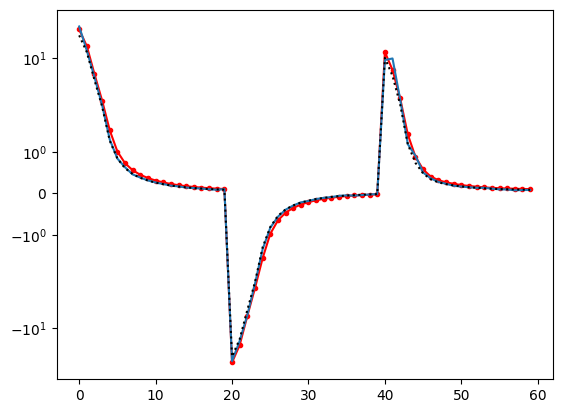

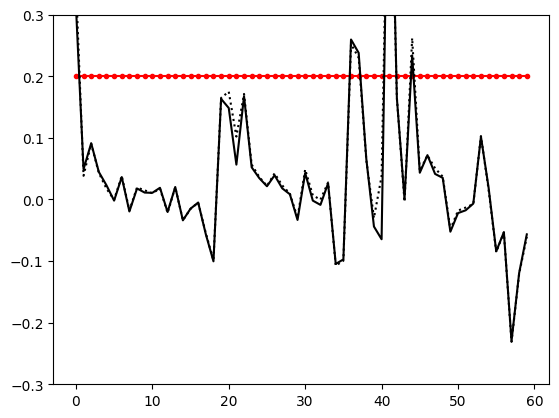

step: 199 0.20906016760958848
step: 200 0.20906016760958848


In [24]:
from datetime import datetime, timedelta
from jax.scipy.optimize import minimize

from multiprocessing.pool import ThreadPool as Pool 
pool = Pool() #jax pmap? check re-compilation times?
pmap = pool.map

#method = 'L-BFGS-B'
method = "l-bfgs-experimental-do-not-rely-on-this"
θ_rtol = 1e-5
z_rtol = 1e-5

θ_tol = 1e-5
z_tol = 1e-6

history = []
α=0.7
beta = 0.25

θ̃ = start_point
θ = start_point# if result.θ is not None else θ_start)
θL = start_point
Nθ = len(ravel_θ(θ̃))
time = timedelta(0)
for i in range(1, maxsteps+1):
        print("step:",i,α)
        t0 = datetime.now()

        if i > 1:
            xs = [x_data] + [prob.sample_x_z(_rng, θ)[0] for _rng in _split_rng(rng,nsims)]
            θ_tol = np.sqrt(-np.diag(H̃_inv_post)) * θ_rtol

        if i > 2:
            Δθ̃ = ravel_θ(history[-1]["θ̃"])- ravel_θ(history[-2]["θ̃"])
          #  if np.sqrt(-np.inner(Δθ̃, np.inner(np.linalg.pinv(history[-1]["H̃_inv_post"]), Δθ̃))) < θ_rtol:
           #     break

        # MUSE gradient
        def get_MAPs(x_z):
            x, ẑ_prev = x_z
            result = prob.z_MAP_and_score(x, ẑ_prev, θ, method=method, z_tol=z_tol, θ_tol=θ_tol)
            
            return result

        MAPs = list(pmap(get_MAPs, zip(xs, ẑs)))

        ẑs = [MAP.z for MAP in MAPs]
   #     if save_MAP_history:
    #        MAP_history_dat, *MAP_history_sims = [MAP.history for MAP in MAPs]
        s_MAP_dat, *s_MAP_sims = [MAP.s for MAP in MAPs]
        s̃_MAP_dat, *s̃_MAP_sims = [MAP.s̃ for MAP in MAPs]
        s̃_MUSE = unravel_θ(ravel_θ(s̃_MAP_dat) - np.nanmean(np.stack(list(map(ravel_θ, s̃_MAP_sims))), axis=0))
        s̃_prior, H̃_prior = gradθ_hessθ_logPrior(θ̃, transformed_θ=True)
        s̃_post = unravel_θ(ravel_θ(s̃_MUSE) + ravel_θ(s̃_prior))

        # print(s̃_MAP_sims)
        # H̃_inv_like_sims = np.diag(-1 / np.nanvar(np.stack(list(map(ravel_θ, s̃_MAP_sims))), axis=0))
        epsilon = 1e-8  # A small value to avoid division by zero
        variance = np.nanvar(np.stack(list(map(ravel_θ, s̃_MAP_sims))), axis=0)
        variance += epsilon  # Add epsilon to the variance to prevent zero values
        H̃_inv_like_sims = np.diag(-1 / variance)
        # print(H̃_inv_like_sims)
        
       # try:
        # H̃_inv_post = np.linalg.pinv(np.linalg.pinv(H̃_inv_like_sims) + ravel_θ(H̃_prior).reshape(Nθ,Nθ))
        H̃_inv_post = np.linalg.pinv(np.linalg.pinv(H̃_inv_like_sims) + ravel_θ(H̃_prior).reshape(Nθ,Nθ))
        #except:
        #    print("error on Hessian inversion calc, prior ignored and trying again...")
       # H̃_inv_post = H̃_inv_like_sims
        t = datetime.now() - t0
        time += t

        history.append({
            "t":t, "θ̃":θ̃, "θ":θ,
            "s_MAP_dat": s_MAP_dat, "s_MAP_sims": s_MAP_sims,
            "s̃_MAP_dat": s̃_MAP_dat, "s̃_MAP_sims": s̃_MAP_sims, 
            "s̃_MUSE": s̃_MUSE,
            "s̃_prior": s̃_prior, "s̃_post": s̃_post, 
            "H̃_inv_post": H̃_inv_post, "H̃_prior": H̃_prior, 
            "H̃_inv_like_sims": H̃_inv_like_sims,
            "θ_tol": θ_tol,
        #    "MAP_history_dat": MAP_history_dat, 
         #   "MAP_history_sims": MAP_history_sims,
        })
        θ̃update = np.clip((np.inner(H̃_inv_post, ravel_θ(s̃_post))),-jnp.abs(ravel_θ(θ̃)*beta),jnp.abs(ravel_θ(θ̃)*beta))
        θ̃ = unravel_θ((ravel_θ(θ̃) - α * θ̃update))
        θ = θ̃
        # print(((θ-tf_cut_flat)/tf_cut_flat))
        #print(θ)
        if i%3==0:
            plt.plot(start_point,"r.-")
            plt.plot(θ)
            plt.plot(tf_cut_flat,"k:")
            plt.yscale("symlog")
            plt.show()
            
            
            plt.plot((start_point-tf_cut_flat)/tf_cut_flat,"r.-")
            plt.plot((θ-tf_cut_flat)/tf_cut_flat,"k")
            plt.plot((θL-tf_cut_flat)/tf_cut_flat,"k:")
    
            plt.ylim([-.3,.3])
            plt.show()
            
            θL = θ
            #LR decay
            if i%150==0 and i!=0:
                α = 0.5
            α *= 0.95

In [1]:
(150/0.6711/2.5)**2

7993.335157145971

In [25]:
#as you can see, convergence properties are wonky, takes a bit of time to start moving... 
#Should converge if you have the patients to let it run a couple of hours


In [26]:
#Now lets try to calculate the covariance! :D

In [27]:
s_MAP_sims = history[-1]["s_MAP_sims"]
_, *z_MAP_sims = ẑs

In [28]:
def z_MAP_guess_from_truth(x, z, θ):
        return unravel_z(0 * ravel_z(z))
    
nsims = 1
    
def get_J(
        result = None,
        θ = None,
        θ_tol = None,
        z_tol = None,
        method = None,
        rng = None,
        nsims = 10, 
        pmap = map,
        progress = False, 
        skip_errors = False,
    ):

        nsims_remaining = nsims 

        if nsims_remaining > 0:
            print(nsims_remaining)
            # t0 = datetime.now()

            def get_s_MAP(rng):
                    (x, z) = prob.sample_x_z(rng, θ)
                    # if np.isnan(x).any() or np.isnan(z).any():
                    #     print("NaN detected in sampled (x, z)")
                    #     return None                    
                    z_MAP_guess = prob.z_MAP_guess_from_truth(x, z, θ)
                    # if np.isnan(z_MAP_guess).any():
                    #     print("NaN detected in z_MAP_guess!")
                    #     return None

                    #     result = prob.z_MAP_and_score(x, z_MAP_guess, θ, method=method, θ_tol=θ_tol, z_tol=z_tol)
                    #     if np.isnan(result.s).any():
                    #         print("NaN detected in s_MAP!")
                    #         return None
                    return prob.z_MAP_and_score(x, z_MAP_guess, θ, method=method, θ_tol=θ_tol, z_tol=z_tol).s
                

            rngs = _split_rng(rng, nsims_remaining)
            s_MAP_sims.extend(s for s in pmap(get_s_MAP, rngs) if s is not None)

#            time += datetime.now() - t0

        stacked_s = np.stack(list(map(ravel_θ, s_MAP_sims)))
        print("Stacked s_MAP_sims shape:", stacked_s.shape)
        print("Stacked s_MAP_sims values:", stacked_s)
        
        if np.isnan(stacked_s).any():
            print("NaN detected in stacked_s before computing J!")
            exit()
        J = np.atleast_2d(np.cov(np.stack(list(map(ravel_θ, s_MAP_sims))), rowvar=False))
        return J



In [29]:
J = get_J(rng=rng,θ =θ,method=method, θ_tol=θ_tol, z_tol=z_tol)

10
Stacked s_MAP_sims shape: (20, 60)
Stacked s_MAP_sims values: [[ 2.4210241e+00  6.5005035e+01  4.3812708e+02 ... -3.4142242e+04
  -2.0244812e+04 -9.0492109e+03]
 [ 2.6480341e+00  6.7857872e+01  4.2750116e+02 ... -3.3875094e+04
  -1.9855320e+04 -8.7935186e+03]
 [ 2.7769449e+00  6.1709892e+01  4.3322040e+02 ... -3.3689727e+04
  -2.0270518e+04 -8.9844521e+03]
 ...
 [-5.7209766e+01 -4.1733420e+02 -2.7471771e+02 ... -2.2790545e+04
  -1.2642248e+04 -5.3166787e+03]
 [-5.6795639e+01 -1.9040115e+01  8.0945099e+02 ... -2.2423410e+04
  -1.2449215e+04 -5.3560176e+03]
 [-1.8317638e+01 -7.6615540e+01  2.6450565e+02 ... -2.6156867e+04
  -1.5073035e+04 -6.6648535e+03]]


In [30]:
J

array([[2.97911511e+08, 1.41633114e+09, 1.18381390e+09, ...,
        2.16985934e+07, 1.34743166e+07, 5.82069334e+06],
       [1.41633114e+09, 6.74526463e+09, 5.63604001e+09, ...,
        1.03132570e+08, 6.34025919e+07, 2.71971303e+07],
       [1.18381390e+09, 5.63604001e+09, 4.70963166e+09, ...,
        8.59225096e+07, 5.28962493e+07, 2.27087500e+07],
       ...,
       [2.16985934e+07, 1.03132570e+08, 8.59225096e+07, ...,
        2.20238314e+07, 1.44304843e+07, 6.72769574e+06],
       [1.34743166e+07, 6.34025919e+07, 5.28962493e+07, ...,
        1.44304843e+07, 9.54593126e+06, 4.46243648e+06],
       [5.82069334e+06, 2.71971303e+07, 2.27087500e+07, ...,
        6.72769574e+06, 4.46243648e+06, 2.09333938e+06]])

In [32]:
cond_number = np.linalg.cond(J)
print(f"Condition number of J: {cond_number}")
if cond_number > 1e12:
    print("Warning: J is nearly singular!")

Condition number of J: 3.5220583854165675e+20


In [33]:
Hs = []

In [34]:
def pjacobian(f, x, step, pmap=map, pbar=None):
    print(step,x)
    step = step + np.array(0 * x) # make array if scalar

    def column(i):
    
        def v(ε):
            ε_vec = np.array(0 * x)
            ε_vec[i] = ε
            v = f(x + ε_vec)
            if pbar: pbar.update()
            return v

        return (v(step[i]) - v(-step[i])) / (2 * step[i])

    return np.array(list(pmap(column, range(len(x)))))

In [35]:
#This takes a while, roughly an hour or two... Can probably parallelize it across GPUs if you want.

from tqdm import tqdm
from jax.scipy.sparse.linalg import cg

step = None
skip_errors = False
def _get_H_i_old(rng, z_MAP_guess_fid, *, θ, method=None, θ_tol=None, z_tol=None, step=None, skip_errors=False):
    
    # for each sim, do one fit at fiducial which we'll
    # reuse as a starting point when fudging θ by +/-ϵ
    θfid = θ
    (x, z) = prob.sample_x_z(rng, θfid)
    if z_MAP_guess_fid is None:
        z_MAP_guess = _MAP_guess_from_truth(x, z, θfid)
        z_MAP_guess_fid = z_MAP_and_score(x, z_MAP_guess, θfid, method=method, θ_tol=θ_tol, z_tol=z_tol).z

    def get_s_MAP(θvec):
        θ = unravel_θ(θvec)
        (x, _) = prob.sample_x_z(copy(rng), θ)
        return ravel_θ(prob.z_MAP_and_score(x, z_MAP_guess_fid, θfid, method=method, θ_tol=θ_tol, z_tol=z_tol).s)

    return pjacobian(get_s_MAP, ravel_θ(θfid), step)


def _get_H_i(rng, z_MAP, *, θ, implicit_diff_cgtol=1e-3, method=None, θ_tol=None, z_tol=None, step=None, skip_errors=False):

        #implicit implementation..
        cg_kwargs = dict(tol=implicit_diff_cgtol)

        (x, z) = prob.sample_x_z(rng, θ)
        if z_MAP is None:
            z_MAP_guess = z_MAP_guess_from_truth(x, z, θ)
            z_MAP = prob.z_MAP_and_score(x, z_MAP_guess, θ, method=method, θ_tol=θ_tol, z_tol=z_tol).z

        θ_vec, z_MAP_vec = ravel_θ(θ), ravel_z(z_MAP)
        #unravel_θ, unravel_z = unravel_θ, unravel_z

        # non-implicit-diff term
        H1 = jacfwd(
            lambda θ1: grad(
                lambda θ2: prob.logLike(prob.sample_x_z(rng, unravel_θ(θ1))[0], z_MAP, unravel_θ(θ2))
            )(θ_vec)
        )(θ_vec)

        # term involving dzMAP/dθ via implicit-diff (w/ conjugate-gradient linear solve)
        dFdθ = jacfwd(
            lambda θ: grad(
                lambda z: prob.logLike(x, unravel_z(z), unravel_θ(θ))
            )(z_MAP_vec)
        )(θ_vec)
        dFdθ1 = jacfwd(
            lambda θ1: grad(
                lambda z: prob.logLike(prob.sample_x_z(rng, unravel_θ(θ1))[0], unravel_z(z), θ)
            )(z_MAP_vec)
        )(θ_vec)
        inv_dFdz_dFdθ1 = vmap(
            lambda vec: cg(
                lambda vec: jvp(lambda z: grad(lambda z: prob.logLike(x, unravel_z(z), θ))(z), (z_MAP_vec,), (vec,))[1], 
                vec, 
                **cg_kwargs
            )[0], 
            in_axes=1, out_axes=1
        )(dFdθ1)
        H2 = -dFdθ.T @ inv_dFdz_dFdθ1
        return H1 + H2

Hs = []

nsims_remaining = nsims  #- len(result.Hs)

z_MAP_sims = z_MAP_sims[:4]

if nsims_remaining > 0:

    # default to finite difference step size of 0.1σ with σ roughly
    # estimated from s_MAP_sims sims, if we have them
    if step is None:
        if len(s_MAP_sims) > 0:
            step = 0.1 / np.std(np.stack(list(map(ravel_θ, s_MAP_sims))), axis=0)
        else:
            step = 1e-5
    
    Nθ = len(ravel_θ(θ))
    pbar = partial(tqdm, total=nsims_remaining, desc="get_H", disable=(True))

    # t0 = datetime.now()
    rngs = _split_rng(rng, nsims)[-nsims_remaining:]
    z_MAP_sims = (z_MAP_sims + [None]*(max(0, nsims - len(z_MAP_sims))))[-nsims_remaining:]
    _get_H_ii = partial(_get_H_i, θ=θ, method=method, θ_tol=θ_tol, z_tol=z_tol, step=step, skip_errors=skip_errors)
    Hs.extend(H for H in pbar(map(lambda args: _get_H_ii(*args), zip(rngs, z_MAP_sims)) )if H is not None)
   # result.time += datetime.now() - t0

avg = np.mean#np.median if use_median else np.mean
H = avg(np.array(Hs), axis=0)

In [36]:
Hs[0]

Array([[-1.4841545e+01,  1.7032352e+02,  5.8663265e+01, ...,
        -3.6766247e+01, -6.3855934e+00,  5.0900048e-01],
       [ 8.0252945e+01,  3.4311978e+03,  2.4572461e+03, ...,
         3.9734581e+01,  2.6920280e+01, -7.5350493e-01],
       [-5.3725433e+00,  2.2134758e+03,  2.1126936e+04, ...,
         1.0989323e+01, -3.4588974e+01,  2.2241144e+00],
       ...,
       [ 2.1297860e-01,  1.4302111e+00,  8.3945160e+00, ...,
         1.3173511e+05,  4.0139254e+04,  6.2487900e+03],
       [ 3.9601400e-02,  4.5621538e-01,  4.5708251e+00, ...,
         4.0462641e+04,  6.1930602e+04,  1.4629729e+04],
       [ 8.6364895e-04, -1.9779801e-04,  2.1967542e-01, ...,
         6.3942207e+03,  1.4605873e+04,  1.7546906e+04]], dtype=float32)

In [37]:
import scipy as sp

Nθ = len(ravel(θ))

H_prior = -ravel(prob.gradθ_hessθ_logPrior(θ, transformed_θ=False)[1]).reshape(Nθ,Nθ)
Σ_inv = H.T @ np.linalg.pinv(J) @ H + H_prior
Σ = np.linalg.pinv(Σ_inv)

try:
    if θ is not None:
        if Nθ == 1:
            dist = sp.stats.norm(ravel(θ), np.sqrt(Σ[0,0]))
        else:
            dist = sp.stats.multivariate_normal(ravel(θ), Σ)
except:
    print("likely error in covariance... proceed with caution!")

likely error in covariance... proceed with caution!


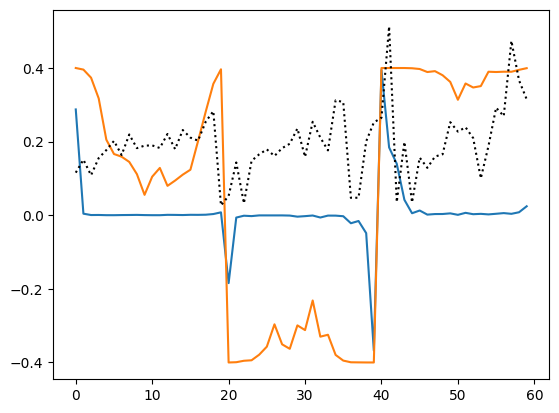

In [38]:
plt.plot(1/np.sqrt(np.diag(Σ_inv))/tf_cut_flat)
plt.plot(np.sqrt(np.diag(Σ))/tf_cut_flat)

plt.plot(abs((start_point-θ)/tf_cut_flat),"k:")

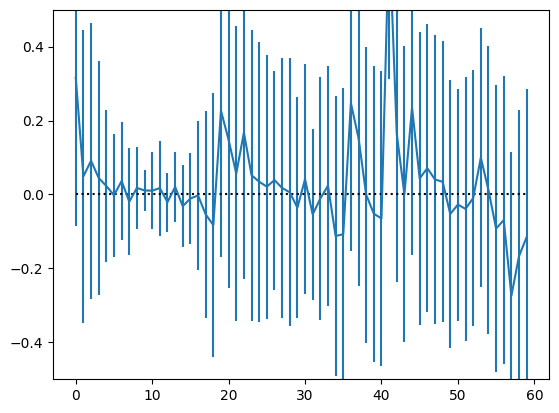

In [39]:
#need to run optimization for longer, since thsoe smaller scale modes in each mu-bin are not converged...
# plt.errorbar(np.arange(len(tf_cut_flat)),(θ-tf_cut_flat)/tf_cut_flat,yerr=np.abs(1/np.sqrt(np.diag(Σ_inv))/tf_cut_flat))
plt.errorbar(np.arange(len(tf_cut_flat)),(θ-tf_cut_flat)/tf_cut_flat,yerr = np.abs(np.sqrt(np.diag(Σ)) / tf_cut_flat))
plt.plot(np.arange(len(tf_cut_flat)),np.arange(len(tf_cut_flat))*0.0,"k:")
plt.ylim(-0.5,0.5)
plt.show()

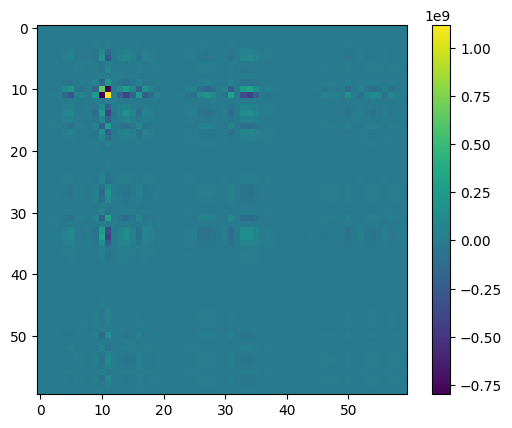

In [41]:
imshow(Σ_inv)
colorbar()

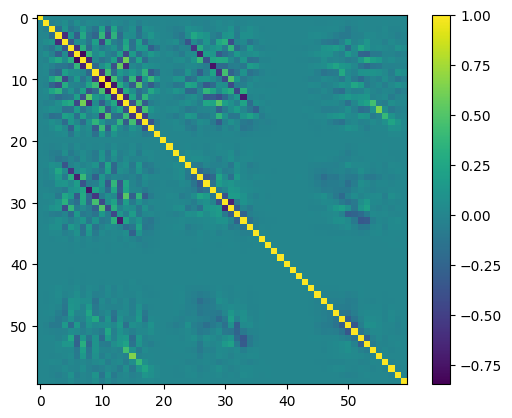

In [44]:
Σ_iijj = np.zeros(Σ_inv.shape)
for i in range(Σ_inv.shape[0]):
    for j in range(Σ_inv.shape[1]):
       Σ_iijj[i,j] = np.sqrt(Σ[i,i]*Σ[j,j])
imshow(Σ/Σ_iijj)
colorbar()

In [45]:
#test

In [72]:
s_MAP_sims = history[-1]["s_MAP_sims"]
_, *z_MAP_sims = ẑs

In [73]:
def z_MAP_guess_from_truth(x, z, θ):
        return unravel_z(0 * ravel_z(z))
    
nsims = 50
    
def get_J(
        result = None,
        θ = None,
        θ_tol = None,
        z_tol = None,
        method = None,
        rng = None,
        nsims = 10, 
        pmap = map,
        progress = False, 
        skip_errors = False,
    ):

        nsims_remaining = nsims 

        if nsims_remaining > 0:
            print(nsims_remaining)
            # t0 = datetime.now()

            def get_s_MAP(rng):
                    (x, z) = prob.sample_x_z(rng, θ)
                    # if np.isnan(x).any() or np.isnan(z).any():
                    #     print("NaN detected in sampled (x, z)")
                    #     return None                    
                    z_MAP_guess = prob.z_MAP_guess_from_truth(x, z, θ)
                    # if np.isnan(z_MAP_guess).any():
                    #     print("NaN detected in z_MAP_guess!")
                    #     return None

                    #     result = prob.z_MAP_and_score(x, z_MAP_guess, θ, method=method, θ_tol=θ_tol, z_tol=z_tol)
                    #     if np.isnan(result.s).any():
                    #         print("NaN detected in s_MAP!")
                    #         return None
                    return prob.z_MAP_and_score(x, z_MAP_guess, θ, method=method, θ_tol=θ_tol, z_tol=z_tol).s
                

            rngs = _split_rng(rng, nsims_remaining)
            s_MAP_sims.extend(s for s in pmap(get_s_MAP, rngs) if s is not None)

#            time += datetime.now() - t0

        stacked_s = np.stack(list(map(ravel_θ, s_MAP_sims)))
        print("Stacked s_MAP_sims shape:", stacked_s.shape)
        print("Stacked s_MAP_sims values:", stacked_s)
        
        if np.isnan(stacked_s).any():
            print("NaN detected in stacked_s before computing J!")
            exit()
        J = np.atleast_2d(np.cov(np.stack(list(map(ravel_θ, s_MAP_sims))), rowvar=False))
        return J



In [74]:
J = get_J(rng=rng,θ =θ,method=method, θ_tol=θ_tol, z_tol=z_tol)

10
Stacked s_MAP_sims shape: (50, 60)
Stacked s_MAP_sims values: [[ 2.4210241e+00  6.5005035e+01  4.3812708e+02 ... -3.4142242e+04
  -2.0244812e+04 -9.0492109e+03]
 [ 2.6480341e+00  6.7857872e+01  4.2750116e+02 ... -3.3875094e+04
  -1.9855320e+04 -8.7935186e+03]
 [ 2.7769449e+00  6.1709892e+01  4.3322040e+02 ... -3.3689727e+04
  -2.0270518e+04 -8.9844521e+03]
 ...
 [-1.0316867e-01  2.6487301e+01  2.9904895e+02 ... -3.0951207e+04
  -1.7894285e+04 -7.7175303e+03]
 [-1.5162969e-01  2.5784168e+01  3.8842392e+02 ... -2.9114691e+04
  -1.6719443e+04 -7.4198726e+03]
 [ 5.3582329e-01  7.0344147e+01  4.5316736e+02 ... -3.3437273e+04
  -1.9721832e+04 -8.8030938e+03]]


In [75]:
J

array([[1.22614570e+08, 5.82406618e+08, 4.86171466e+08, ...,
        9.29838894e+06, 6.00021507e+06, 2.63302093e+06],
       [5.82406618e+08, 2.77172704e+09, 2.31590734e+09, ...,
        4.78561546e+07, 3.03743480e+07, 1.32521168e+07],
       [4.86171466e+08, 2.31590734e+09, 1.94592283e+09, ...,
        5.34886620e+07, 3.31792372e+07, 1.44867263e+07],
       ...,
       [9.29838894e+06, 4.78561546e+07, 5.34886620e+07, ...,
        3.68821840e+07, 2.28187853e+07, 1.02840535e+07],
       [6.00021507e+06, 3.03743480e+07, 3.31792372e+07, ...,
        2.28187853e+07, 1.42412848e+07, 6.43589223e+06],
       [2.63302093e+06, 1.32521168e+07, 1.44867263e+07, ...,
        1.02840535e+07, 6.43589223e+06, 2.91575102e+06]])

In [76]:
cond_number = np.linalg.cond(J)
print(f"Condition number of J: {cond_number}")
if cond_number > 1e12:
    print("Warning: J is nearly singular!")

Condition number of J: 8.492088445818619e+18


In [77]:
Hs = []

In [78]:
def pjacobian(f, x, step, pmap=map, pbar=None):
    print(step,x)
    step = step + np.array(0 * x) # make array if scalar

    def column(i):
    
        def v(ε):
            ε_vec = np.array(0 * x)
            ε_vec[i] = ε
            v = f(x + ε_vec)
            if pbar: pbar.update()
            return v

        return (v(step[i]) - v(-step[i])) / (2 * step[i])

    return np.array(list(pmap(column, range(len(x)))))

In [79]:
#This takes a while, roughly an hour or two... Can probably parallelize it across GPUs if you want.

from tqdm import tqdm
from jax.scipy.sparse.linalg import cg

step = None
skip_errors = False
def _get_H_i_old(rng, z_MAP_guess_fid, *, θ, method=None, θ_tol=None, z_tol=None, step=None, skip_errors=False):
    
    # for each sim, do one fit at fiducial which we'll
    # reuse as a starting point when fudging θ by +/-ϵ
    θfid = θ
    (x, z) = prob.sample_x_z(rng, θfid)
    if z_MAP_guess_fid is None:
        z_MAP_guess = _MAP_guess_from_truth(x, z, θfid)
        z_MAP_guess_fid = z_MAP_and_score(x, z_MAP_guess, θfid, method=method, θ_tol=θ_tol, z_tol=z_tol).z

    def get_s_MAP(θvec):
        θ = unravel_θ(θvec)
        (x, _) = prob.sample_x_z(copy(rng), θ)
        return ravel_θ(prob.z_MAP_and_score(x, z_MAP_guess_fid, θfid, method=method, θ_tol=θ_tol, z_tol=z_tol).s)

    return pjacobian(get_s_MAP, ravel_θ(θfid), step)


def _get_H_i(rng, z_MAP, *, θ, implicit_diff_cgtol=1e-3, method=None, θ_tol=None, z_tol=None, step=None, skip_errors=False):

        #implicit implementation..
        cg_kwargs = dict(tol=implicit_diff_cgtol)

        (x, z) = prob.sample_x_z(rng, θ)
        if z_MAP is None:
            z_MAP_guess = z_MAP_guess_from_truth(x, z, θ)
            z_MAP = prob.z_MAP_and_score(x, z_MAP_guess, θ, method=method, θ_tol=θ_tol, z_tol=z_tol).z

        θ_vec, z_MAP_vec = ravel_θ(θ), ravel_z(z_MAP)
        #unravel_θ, unravel_z = unravel_θ, unravel_z

        # non-implicit-diff term
        H1 = jacfwd(
            lambda θ1: grad(
                lambda θ2: prob.logLike(prob.sample_x_z(rng, unravel_θ(θ1))[0], z_MAP, unravel_θ(θ2))
            )(θ_vec)
        )(θ_vec)

        # term involving dzMAP/dθ via implicit-diff (w/ conjugate-gradient linear solve)
        dFdθ = jacfwd(
            lambda θ: grad(
                lambda z: prob.logLike(x, unravel_z(z), unravel_θ(θ))
            )(z_MAP_vec)
        )(θ_vec)
        dFdθ1 = jacfwd(
            lambda θ1: grad(
                lambda z: prob.logLike(prob.sample_x_z(rng, unravel_θ(θ1))[0], unravel_z(z), θ)
            )(z_MAP_vec)
        )(θ_vec)
        inv_dFdz_dFdθ1 = vmap(
            lambda vec: cg(
                lambda vec: jvp(lambda z: grad(lambda z: prob.logLike(x, unravel_z(z), θ))(z), (z_MAP_vec,), (vec,))[1], 
                vec, 
                **cg_kwargs
            )[0], 
            in_axes=1, out_axes=1
        )(dFdθ1)
        H2 = -dFdθ.T @ inv_dFdz_dFdθ1
        return H1 + H2

Hs = []

nsims_remaining = nsims  #- len(result.Hs)

z_MAP_sims = z_MAP_sims[:4]

if nsims_remaining > 0:

    # default to finite difference step size of 0.1σ with σ roughly
    # estimated from s_MAP_sims sims, if we have them
    if step is None:
        if len(s_MAP_sims) > 0:
            step = 0.1 / np.std(np.stack(list(map(ravel_θ, s_MAP_sims))), axis=0)
        else:
            step = 1e-5
    
    Nθ = len(ravel_θ(θ))
    pbar = partial(tqdm, total=nsims_remaining, desc="get_H", disable=(True))

    # t0 = datetime.now()
    rngs = _split_rng(rng, nsims)[-nsims_remaining:]
    z_MAP_sims = (z_MAP_sims + [None]*(max(0, nsims - len(z_MAP_sims))))[-nsims_remaining:]
    _get_H_ii = partial(_get_H_i, θ=θ, method=method, θ_tol=θ_tol, z_tol=z_tol, step=step, skip_errors=skip_errors)
    Hs.extend(H for H in pbar(map(lambda args: _get_H_ii(*args), zip(rngs, z_MAP_sims)) )if H is not None)
   # result.time += datetime.now() - t0

avg = np.mean#np.median if use_median else np.mean
H = avg(np.array(Hs), axis=0)

In [80]:
Hs[0]

Array([[ 7.1567535e-02,  2.0571899e-01, -2.8921127e-02, ...,
        -6.7987442e-03,  2.3443103e-03,  8.0257654e-05],
       [ 1.8302917e-01,  7.0415039e+00,  5.9436035e+00, ...,
         3.7937164e-02,  2.6814461e-02,  3.2739639e-02],
       [ 3.4313202e-03,  6.1860352e+00,  1.0772656e+02, ...,
        -6.1164856e-02,  7.8394890e-02,  3.0275345e-02],
       ...,
       [ 1.1025429e-02,  2.6676178e-02,  1.2814331e-01, ...,
         5.5200875e+04,  1.6874299e+04,  2.6338198e+03],
       [ 3.6526918e-03,  2.7404785e-02,  3.4516335e-02, ...,
         1.6429576e+04,  2.9439094e+04,  6.8599102e+03],
       [ 2.1484494e-04, -3.8773566e-04,  1.4715195e-02, ...,
         2.4339907e+03,  6.9157363e+03,  9.3895176e+03]], dtype=float32)

In [81]:
import scipy as sp

Nθ = len(ravel(θ))

H_prior = -ravel(prob.gradθ_hessθ_logPrior(θ, transformed_θ=False)[1]).reshape(Nθ,Nθ)
Σ_inv = H.T @ np.linalg.pinv(J) @ H + H_prior
Σ = np.linalg.pinv(Σ_inv)

try:
    if θ is not None:
        if Nθ == 1:
            dist = sp.stats.norm(ravel(θ), np.sqrt(Σ[0,0]))
        else:
            dist = sp.stats.multivariate_normal(ravel(θ), Σ)
except:
    print("likely error in covariance... proceed with caution!")

likely error in covariance... proceed with caution!


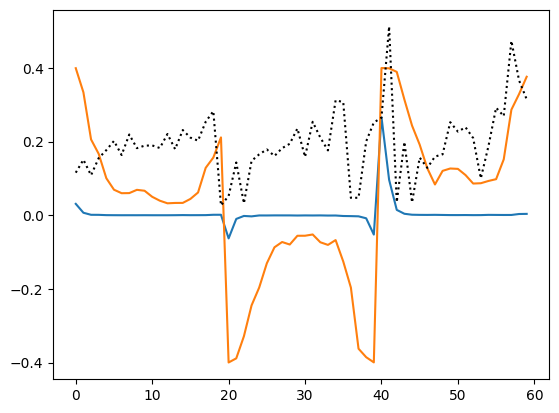

In [82]:
plt.plot(1/np.sqrt(np.diag(Σ_inv))/tf_cut_flat)
plt.plot(np.sqrt(np.diag(Σ))/tf_cut_flat)

plt.plot(abs((start_point-θ)/tf_cut_flat),"k:")

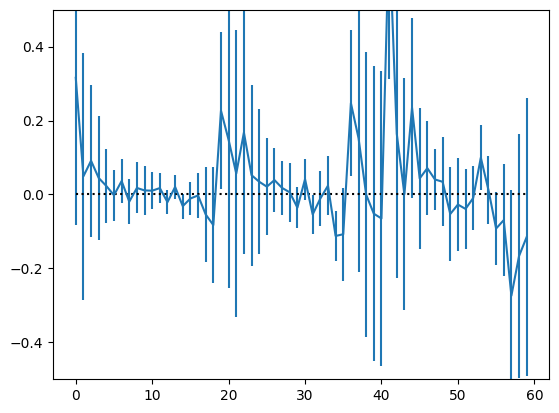

In [83]:
#need to run optimization for longer, since thsoe smaller scale modes in each mu-bin are not converged...
# plt.errorbar(np.arange(len(tf_cut_flat)),(θ-tf_cut_flat)/tf_cut_flat,yerr=np.abs(1/np.sqrt(np.diag(Σ_inv))/tf_cut_flat))
plt.errorbar(np.arange(len(tf_cut_flat)),(θ-tf_cut_flat)/tf_cut_flat,yerr = np.abs(np.sqrt(np.diag(Σ)) / tf_cut_flat))
plt.plot(np.arange(len(tf_cut_flat)),np.arange(len(tf_cut_flat))*0.0,"k:")
plt.ylim(-0.5,0.5)
plt.show()

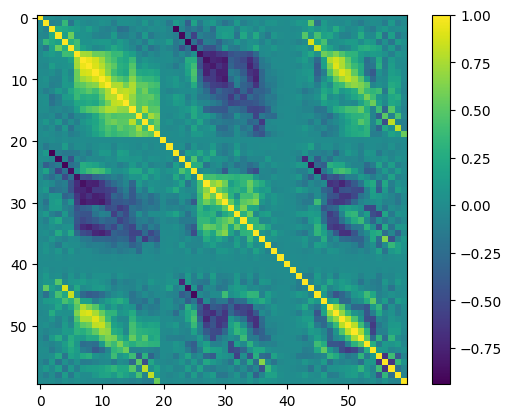

In [84]:
Σ_iijj = np.zeros(Σ_inv.shape)
for i in range(Σ_inv.shape[0]):
    for j in range(Σ_inv.shape[1]):
       Σ_iijj[i,j] = np.sqrt(Σ[i,i]*Σ[j,j])
imshow(Σ/Σ_iijj)
colorbar()